#### EE0005: Introduction to Data Science and Artificial Intelligent - Mini Project

# Topic: Is it possible to predict whether a patient has diabetes based on certain diagnostic measurements?

* Tutorial Group: EE03
* Group: 
* Members:
    1. Foo Kok Cheng
    2. Kant Kaw Khin (U1921816E)
    3. Yeow Jun Wei 
    4. Ho Jia Jun (U1922843G)
    
Dataset Downloaded from Kaggle : Pima Indians Diabetes Database

Source: https://www.kaggle.com/uciml/pima-indians-diabetes-database

# Section A: Cleaning of Data

(Done By: Ho Jia Jun)

# 1. Introduction

Diabetes is a chronic condition associated with abnormally high levels of glucose in the blood. Insulin produced by the pancreas lowers blood glucose. Absence or insufficient production of insulin, or an inability of the body to properly use insulin causes diabetes. If left untreated, diabetes can cause many complications such as cardiovascular disease, stroke, kidney disease, or even death. 

Today, India is facing an epidemic of diabetes, with the highest number of cases stemming from urban areas. With this crisis, it is important to be able to predict if a patient has diabetes from an early stage as the earlier diagnosis is obtained, the much easier we can control the condition. This prediction can also help patients make a preliminary judgment about diabetes according to their daily physical examination data, and it can serve as a reference for their doctors.

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

The objective of our project is to find out if it is possible to use the chosen dataset to predict whether a patient has diabetes, based on certain diagnostic measurements included in the dataset. The project includes the analysis of which combinations of variables and approaches will be able to successfully make predictions through machine learning.

### Importing Basic Libraries 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics


# Import essential models and functions from sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import export_graphviz
from sklearn import metrics
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from pandas import read_csv
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib
matplotlib.use('Agg')
from matplotlib import pyplot
from numpy import loadtxt
from sklearn.metrics import accuracy_score

sb.set_style('darkgrid')
%matplotlib inline
from matplotlib.ticker import FormatStrFormatter
import warnings
warnings.filterwarnings('ignore')



### Importing Raw Dataset and Creating Dataframes

In [2]:

data = pd.read_csv('diabetes.csv')
data_name=data.columns
preg=pd.DataFrame(data['Pregnancies'])
glu=pd.DataFrame(data['Glucose'])
bp=pd.DataFrame(data['BloodPressure'])
st=pd.DataFrame(data['SkinThickness'])
i=pd.DataFrame(data['Insulin'])
bmi=pd.DataFrame(data['BMI'])
dpf=pd.DataFrame(data['DiabetesPedigreeFunction'])
age=pd.DataFrame(data['Age'])
outcome=pd.DataFrame(data['Outcome'])
outcome = outcome.astype('object')




## 2. Data Extraction and Basic Information of Raw Data

In [3]:
data.head()
data.info()
data.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 3. Checking for Missing Data

### 3.1 Visualisation of Missing Data using a Heatmap

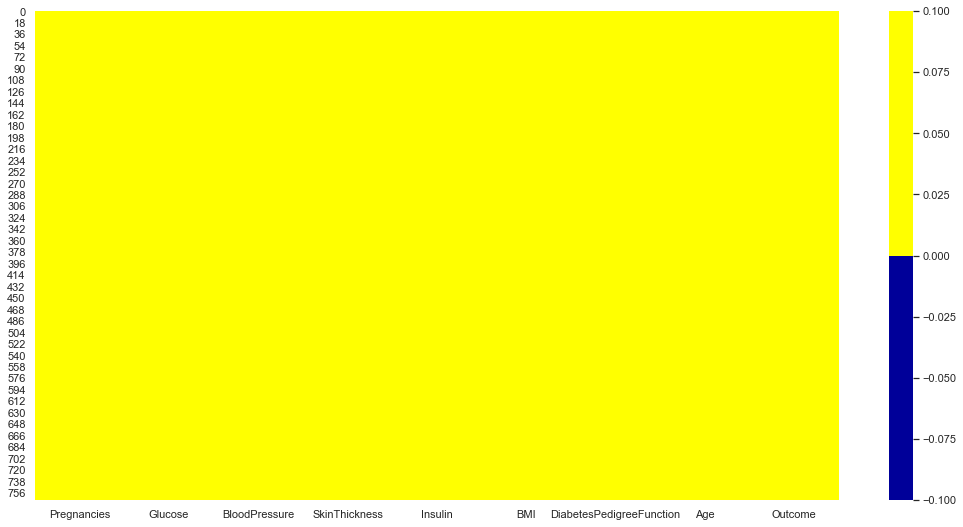

In [4]:
f, axes = plt.subplots(1, 1, figsize=(18, 9))
cols = data.columns[:9] # All columns
colours = ['#000099', '#ffff00'] # Specifying the colours - blue indicates "No Missing Values" while yellow indicates "Missing Values".
sb.heatmap(data[cols].isnull(), cmap=sb.color_palette(colours))

In the heatmap above, the colour blue indicates `Missing Values`, while the colour yellow indicates `No Missing Values`.
Since the heatmap is yellow for all variables, we can conclude that there are no missing values in the dataset.

In [5]:
#Calculating the Percentage of Missing Values for Each Variable
for col in data.columns:
    pct_missing = np.mean(data[col].isnull())
    print('{} - {}%'.format(col, pct_missing*100))

Pregnancies - 0.0%
Glucose - 0.0%
BloodPressure - 0.0%
SkinThickness - 0.0%
Insulin - 0.0%
BMI - 0.0%
DiabetesPedigreeFunction - 0.0%
Age - 0.0%
Outcome - 0.0%


Thus, looking at the heatmap and the percentage values, there are no missing values for all variables in the dataset.

## 4. Checking for Non-Logical Data

### 4.1 Visualisation of Each Variable Using a Histogram

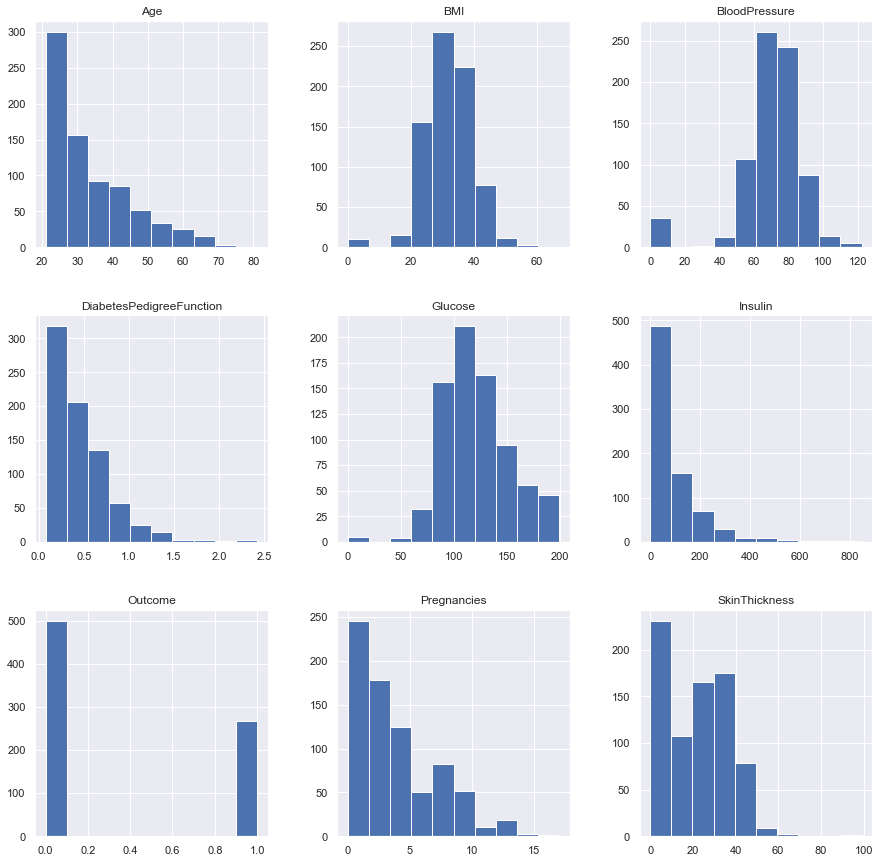

In [6]:
p = data.hist(figsize = (15,15))

Here, we observe that there are non-logical `0` values in the data. Notice how the variables `Glucose`, `Blood Pressure`, `Insulin` and `BMI` contain `0` values. This could be due to inaccurate data reporting, poor transfer of data to CSV or missing values. In any case, we should remove those indexes with non-logical `0` values and replace it with `NaN`.

### 4.2 Scatter Matrix of Uncleaned Data

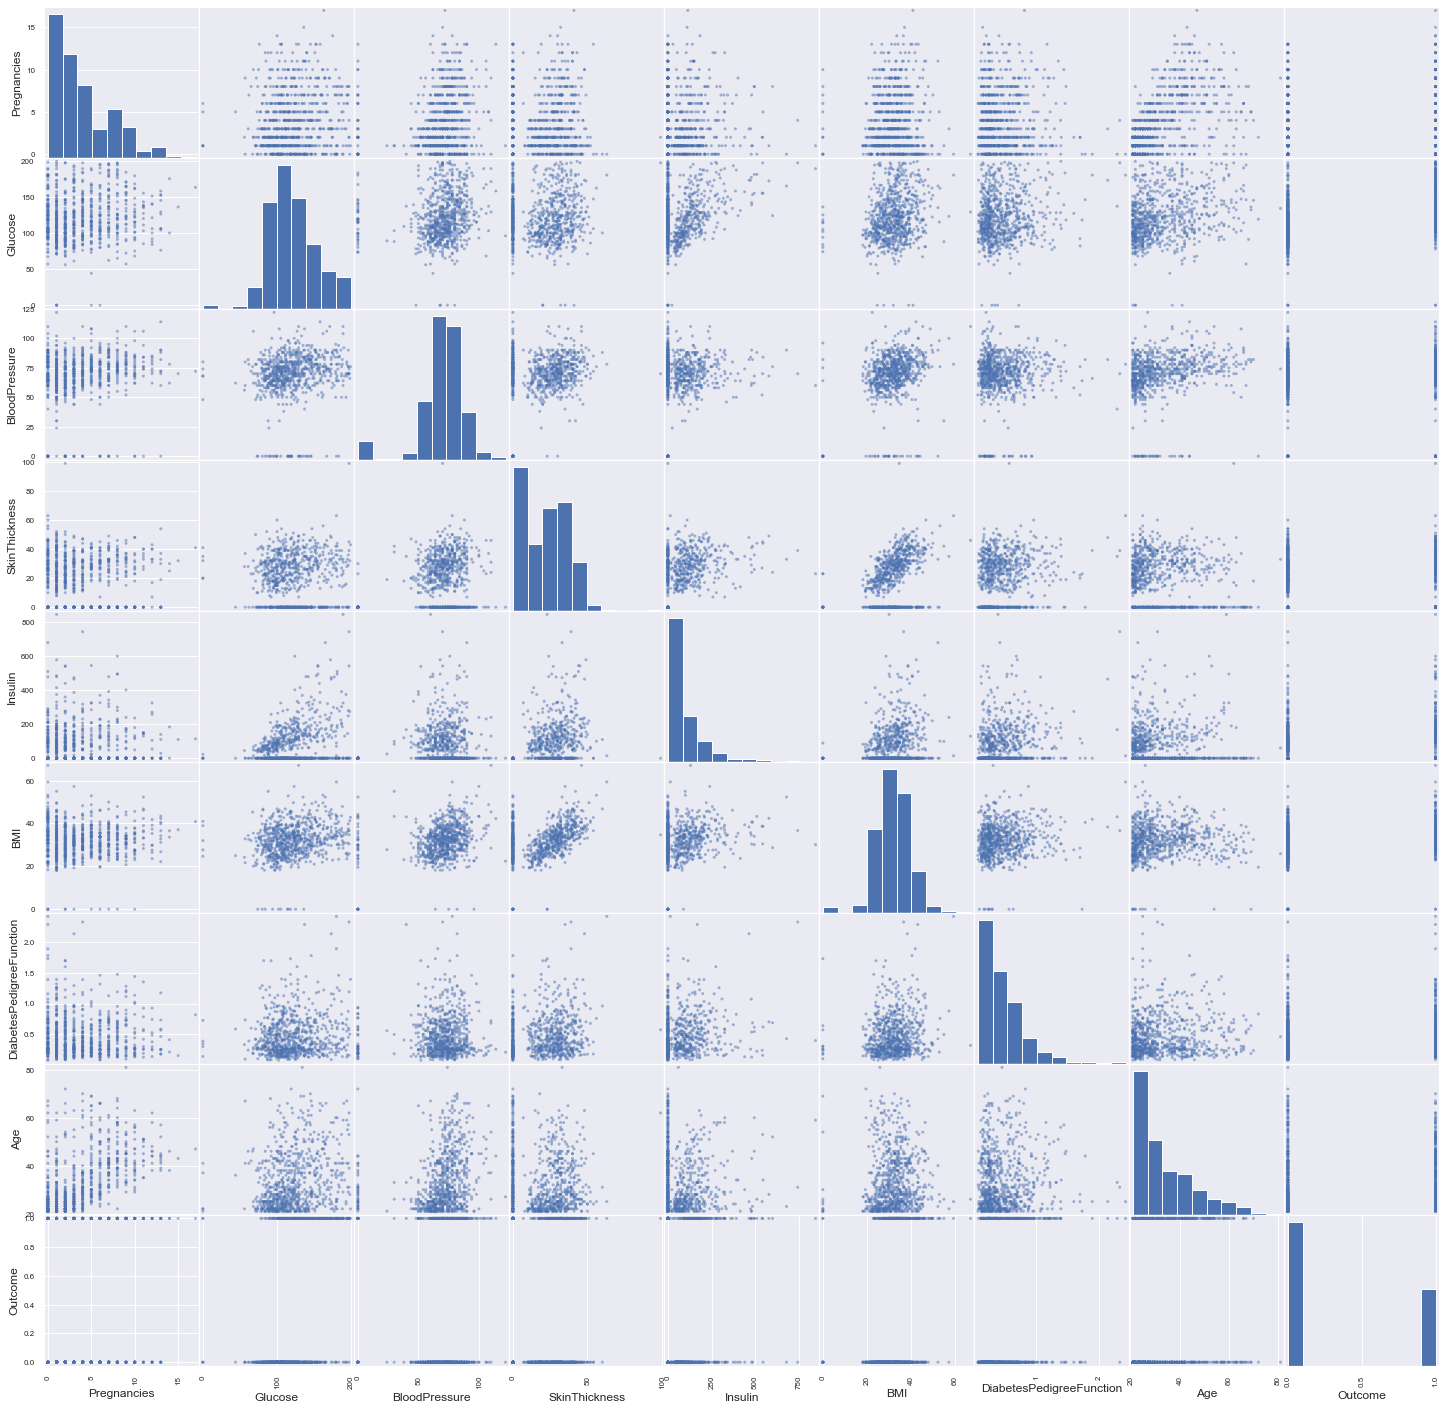

In [7]:
from pandas.plotting import scatter_matrix
p=scatter_matrix(data,figsize=(25, 25))

### 4.3 Replacing `0` Values with `NaN`

In [8]:
df = data.copy(deep = True)
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

## showing the count of Nans
print(df.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


#### 4.3.1 Percentage of `NaN` Values for Each Variable

In [9]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, pct_missing*100))

Pregnancies - 0.0%
Glucose - 0.6510416666666667%
BloodPressure - 4.557291666666666%
SkinThickness - 29.557291666666668%
Insulin - 48.69791666666667%
BMI - 1.4322916666666665%
DiabetesPedigreeFunction - 0.0%
Age - 0.0%
Outcome - 0.0%


### 4.4 Imputation of NaN Values for the Variables in Accordance with their Distribution

In [10]:
df['Glucose'].fillna(df['Glucose'].mean(), inplace = True)
df['BloodPressure'].fillna(df['BloodPressure'].mean(), inplace = True)
df['SkinThickness'].fillna(df['SkinThickness'].median(), inplace = True)
df['Insulin'].fillna(df['Insulin'].median(), inplace = True)
df['BMI'].fillna(df['BMI'].mean(), inplace = True)

* Replace `NaN` Values of `Glucose` with `Mean`
* Replace `NaN` Values of `BloodPressure` with `Mean`
* Replace `NaN` Values of `SkinThickness` with `Median`
* Replace `NaN` Values of `Insulin` with `Median`
* Replace `NaN` Values of `BMI` with `Mean`

### 4.5 Histogram Plot After Imputation

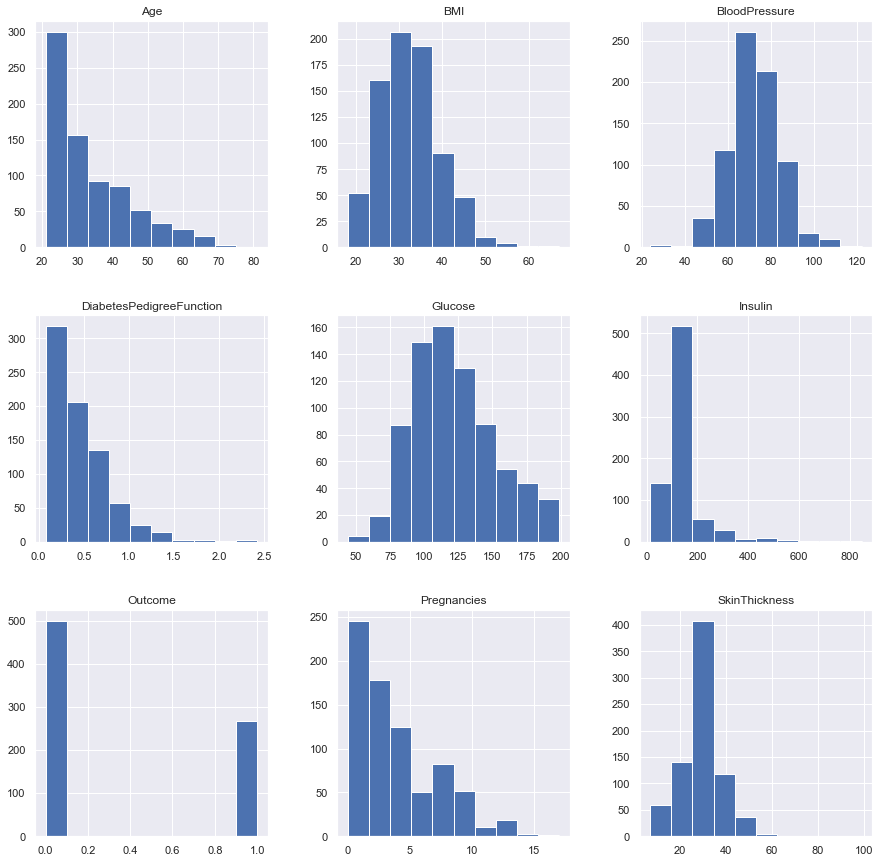

In [11]:
p = df.hist(figsize = (15,15))

# Section B: Explanatory Analysis and Data Visualisation

(Done By: Foo Kok Cheng)

# 1. Explanatory Analysis for the Variable `Pregnancies`

## 1.1 Summary Statistics for `Pregnancies`

In [12]:
#For the variable: Pregnancies

preg_proportion = np.array(df['Pregnancies'].value_counts())
preg_freq = np.array(df['Pregnancies'].value_counts().index)
preg_proportion_perc = np.array(np.round(preg_proportion/sum(preg_proportion),3)*100,dtype=int)

In [13]:
preg = pd.DataFrame({'No. of Pregnancies':preg_freq,'count_of_preg_prop':preg_proportion,'percentage_proportion':preg_proportion_perc})
preg.set_index(['No. of Pregnancies'],inplace=True)
preg.head(10)

,count_of_preg_prop,percentage_proportion
No. of Pregnancies,,
1,135,17
0,111,14
2,103,13
3,75,9
4,68,8
5,57,7
6,50,6
7,45,5
8,38,4


## 1.2 Distribution of the Variable `Pregnancies`and the Distribution Difference in `Pregnancies` Between Diabetic and Non-Diabetic Patients

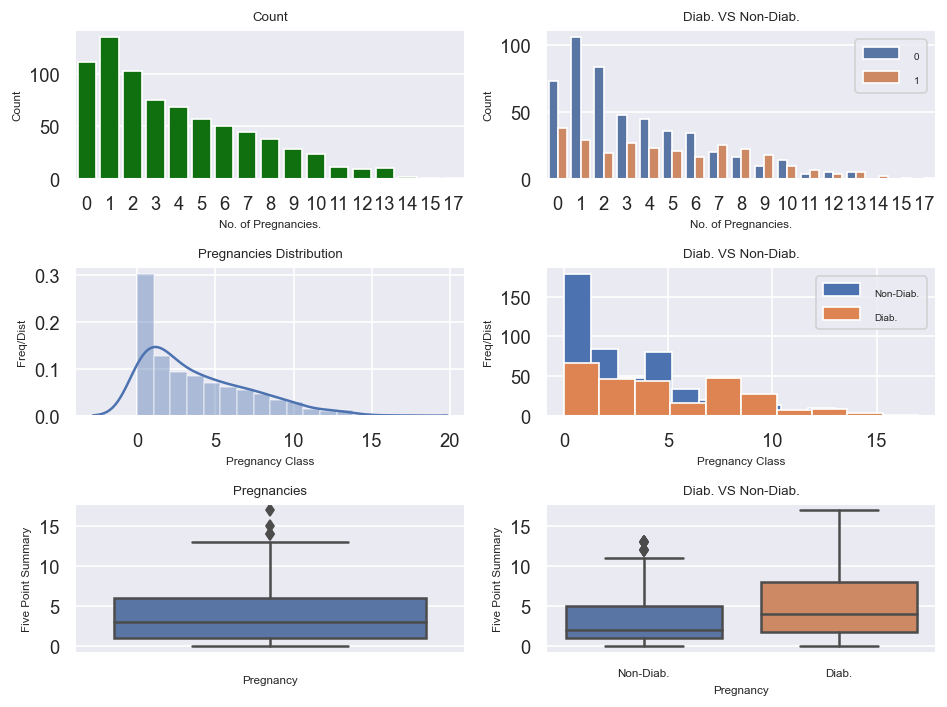

In [14]:
fig,axes = plt.subplots(nrows=3,ncols=2,dpi=120,figsize = (8,6))

# Plotting the count plot of no. of pregnancies 
plot00= sb.countplot('Pregnancies',data=df,ax=axes[0][0],color='green')
axes[0][0].set_title('Count',fontdict={'fontsize':8})
axes[0][0].set_xlabel('No. of Pregnancies.',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count',fontdict={'fontsize':7})
plt.tight_layout()

# # Plotting the count plot showing the difference in the distribution of no. of pregnancies between diabetic and non-diabetic patients
plot01= sb.countplot('Pregnancies',data=df,hue='Outcome',ax=axes[0][1])
axes[0][1].set_title('Diab. VS Non-Diab.',fontdict={'fontsize':8})
axes[0][1].set_xlabel('No. of Pregnancies.',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count',fontdict={'fontsize':7})
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the distribution plot of no. of pregnancies 
plot10 = sb.distplot(df['Pregnancies'],ax=axes[1][0])
axes[1][0].set_title('Pregnancies Distribution',fontdict={'fontsize':8})
axes[1][0].set_xlabel('Pregnancy Class',fontdict={'fontsize':7})
axes[1][0].set_ylabel('Freq/Dist',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of no. of pregnancies between diabetic and non-diabetic patients
plot11 = df[df['Outcome']==False]['Pregnancies'].plot.hist(ax=axes[1][1],label='Non-Diab.')
plot11_2=df[df['Outcome']==True]['Pregnancies'].plot.hist(ax=axes[1][1],label='Diab.')
axes[1][1].set_title('Diab. VS Non-Diab.',fontdict={'fontsize':8})
axes[1][1].set_xlabel('Pregnancy Class',fontdict={'fontsize':7})
axes[1][1].set_ylabel('Freq/Dist',fontdict={'fontsize':7})
plot11.axes.legend(loc=1)
plt.setp(axes[1][1].get_legend().get_texts(), fontsize='6') # for legend text
plt.setp(axes[1][1].get_legend().get_title(), fontsize='6') # for legend title
plt.tight_layout()

# Plotting the boxplot of the no. of pregnancies 
plot20 = sb.boxplot(df['Pregnancies'],ax=axes[2][0],orient='v')
axes[2][0].set_title('Pregnancies',fontdict={'fontsize':8})
axes[2][0].set_xlabel('Pregnancy',fontdict={'fontsize':7})
axes[2][0].set_ylabel('Five Point Summary',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of the no. of pregnancies between diabetic and non-diabetic patients
plot21 = sb.boxplot(x='Outcome',y='Pregnancies',data=df,ax=axes[2][1])
axes[2][1].set_title('Diab. VS Non-Diab.',fontdict={'fontsize':8})
axes[2][1].set_xlabel('Pregnancy',fontdict={'fontsize':7})
axes[2][1].set_ylabel('Five Point Summary',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
plt.tight_layout()
plt.show()

The distribution of `Pregnancies` in the dataset is:
* Unimodal and right-skewed
* Centered at approximately `1`
* Most of the data is between `0` and `15`
* Has a range of approximately `15`
* Outliers are present on the upper end of the distribution

The boxplots comparing the categories (`Diabetic` and `Non-Diabetic`) suggests that patients with higher pregnancy months have higher risk of diabetes.

# 2. Explanatory Analysis for the Variable `Glucose Level`

## 2.1 Summary Statistics for `Glucose Level`

In [15]:
#For the variable: Glucose level

df.Glucose.describe()

count    768.000000
mean     121.686763
std       30.435949
min       44.000000
25%       99.750000
50%      117.000000
75%      140.250000
max      199.000000
Name: Glucose, dtype: float64

## 2.2 Distribution of the Variable `Glucose Level`and the Distribution Difference in `Glucose Level` Between Diabetic and Non-Diabetic Patients

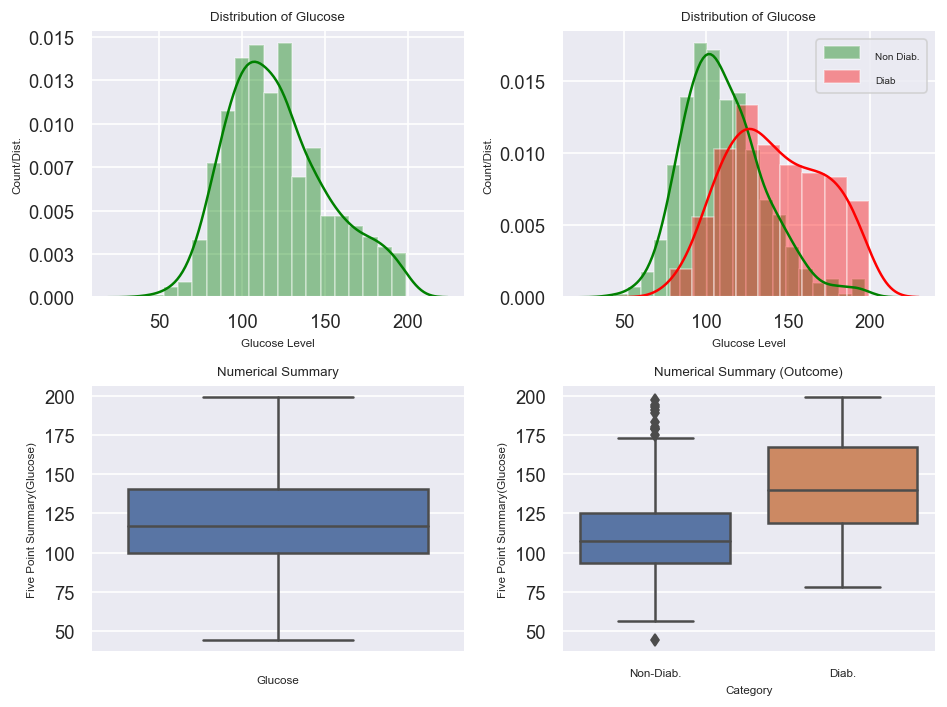

In [16]:
#sb.set_style('darkgrid')
fig,axes = plt.subplots(nrows=2,ncols=2,dpi=120,figsize = (8,6))

# Plotting the distribution plot of Glucose Level 
plot00=sb.distplot(df['Glucose'],ax=axes[0][0],color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of Glucose',fontdict={'fontsize':8})
axes[0][0].set_xlabel('Glucose Level',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of Glucose Levels between diabetic and non-diabetic patients
plot01=sb.distplot(df[df['Outcome']==False]['Glucose'],ax=axes[0][1],color='green',label='Non Diab.')
sb.distplot(df[df.Outcome==True]['Glucose'],ax=axes[0][1],color='red',label='Diab')
axes[0][1].set_title('Distribution of Glucose',fontdict={'fontsize':8})
axes[0][1].set_xlabel('Glucose Level',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the boxplot of Glucose Level 
plot10=sb.boxplot(df['Glucose'],ax=axes[1][0],orient='v')
axes[1][0].set_title('Numerical Summary',fontdict={'fontsize':8})
axes[1][0].set_xlabel('Glucose',fontdict={'fontsize':7})
axes[1][0].set_ylabel(r'Five Point Summary(Glucose)',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of Glucose Levels between diabetic and non-diabetic patients
plot11=sb.boxplot(x='Outcome',y='Glucose',data=df,ax=axes[1][1])
axes[1][1].set_title(r'Numerical Summary (Outcome)',fontdict={'fontsize':8})
axes[1][1].set_ylabel(r'Five Point Summary(Glucose)',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
axes[1][1].set_xlabel('Category',fontdict={'fontsize':7})
plt.tight_layout()

plt.show()

The distribution of `Glucose Level` in the dataset is:
* Unimodal and approximately bell-shaped
* Centered at approximately `115`
* Most of the data between `90` and `140`
* Has a range of approximately `150`

The boxplots comparing the categories (diabetic and non-diabetic) suggests that people with higher glucose levels have higher risk of diabetes.

# 3. Explanatory Analysis for the Variable `Blood Pressure`

## 3.1 Summary Statistics for `Blood Pressure`

In [17]:
df.BloodPressure.describe()

count    768.000000
mean      72.405184
std       12.096346
min       24.000000
25%       64.000000
50%       72.202592
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

## 3.2 Distribution of the Variable `Blood Pressure`and the Distribution Difference in `Blood Pressure` Between Diabetic and Non-Diabetic Patients

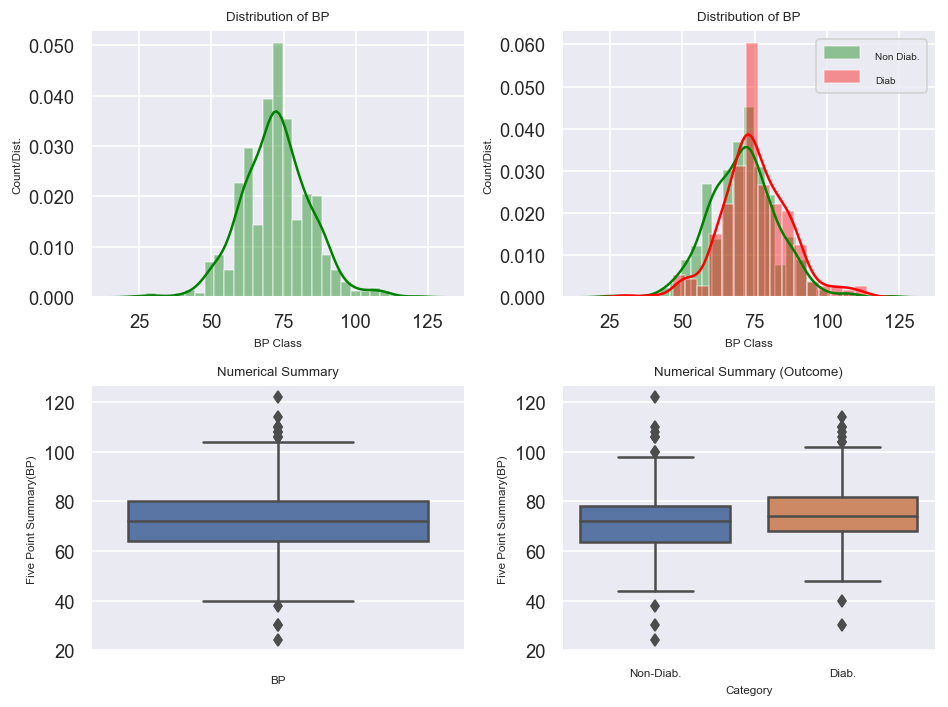

In [18]:
fig,axes = plt.subplots(nrows=2,ncols=2,dpi=120,figsize = (8,6))

# Plotting the distribution plot of Blood Pressure
plot00=sb.distplot(df['BloodPressure'],ax=axes[0][0],color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of BP',fontdict={'fontsize':8})
axes[0][0].set_xlabel('BP Class',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of Blood Pressure between diabetic and non-diabetic patients
plot01=sb.distplot(df[df['Outcome']==False]['BloodPressure'],ax=axes[0][1],color='green',label='Non Diab.')
sb.distplot(df[df.Outcome==True]['BloodPressure'],ax=axes[0][1],color='red',label='Diab')
axes[0][1].set_title('Distribution of BP',fontdict={'fontsize':8})
axes[0][1].set_xlabel('BP Class',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the boxplot of Blood Pressure
plot10=sb.boxplot(df['BloodPressure'],ax=axes[1][0],orient='v')
axes[1][0].set_title('Numerical Summary',fontdict={'fontsize':8})
axes[1][0].set_xlabel('BP',fontdict={'fontsize':7})
axes[1][0].set_ylabel(r'Five Point Summary(BP)',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of Blood Pressure between diabetic and non-diabetic patients
plot11=sb.boxplot(x='Outcome',y='BloodPressure',data=df,ax=axes[1][1])
axes[1][1].set_title(r'Numerical Summary (Outcome)',fontdict={'fontsize':8})
axes[1][1].set_ylabel(r'Five Point Summary(BP)',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
axes[1][1].set_xlabel('Category',fontdict={'fontsize':7})
plt.tight_layout()

plt.show()

The distribution of `Blood Pressure` in the dataset is:
* Unimodal and bell-shaped
* Centered at approximately  `65`
* Most of the data between `60` and `90`
* Has a range of approximately `100`

# 4. Explanatory Analysis for the Variable `Skin Thickness`

## 4.1 Summary Statistics for `Skin Thickness`

In [19]:
# SkinThickness Variable

df.SkinThickness.describe()

count    768.000000
mean      29.108073
std        8.791221
min        7.000000
25%       25.000000
50%       29.000000
75%       32.000000
max       99.000000
Name: SkinThickness, dtype: float64

## 4.2 Distribution of the Variable `Skin Thickness`and the Distribution Difference in `Skin Thickness` Between Diabetic and Non-Diabetic Patients

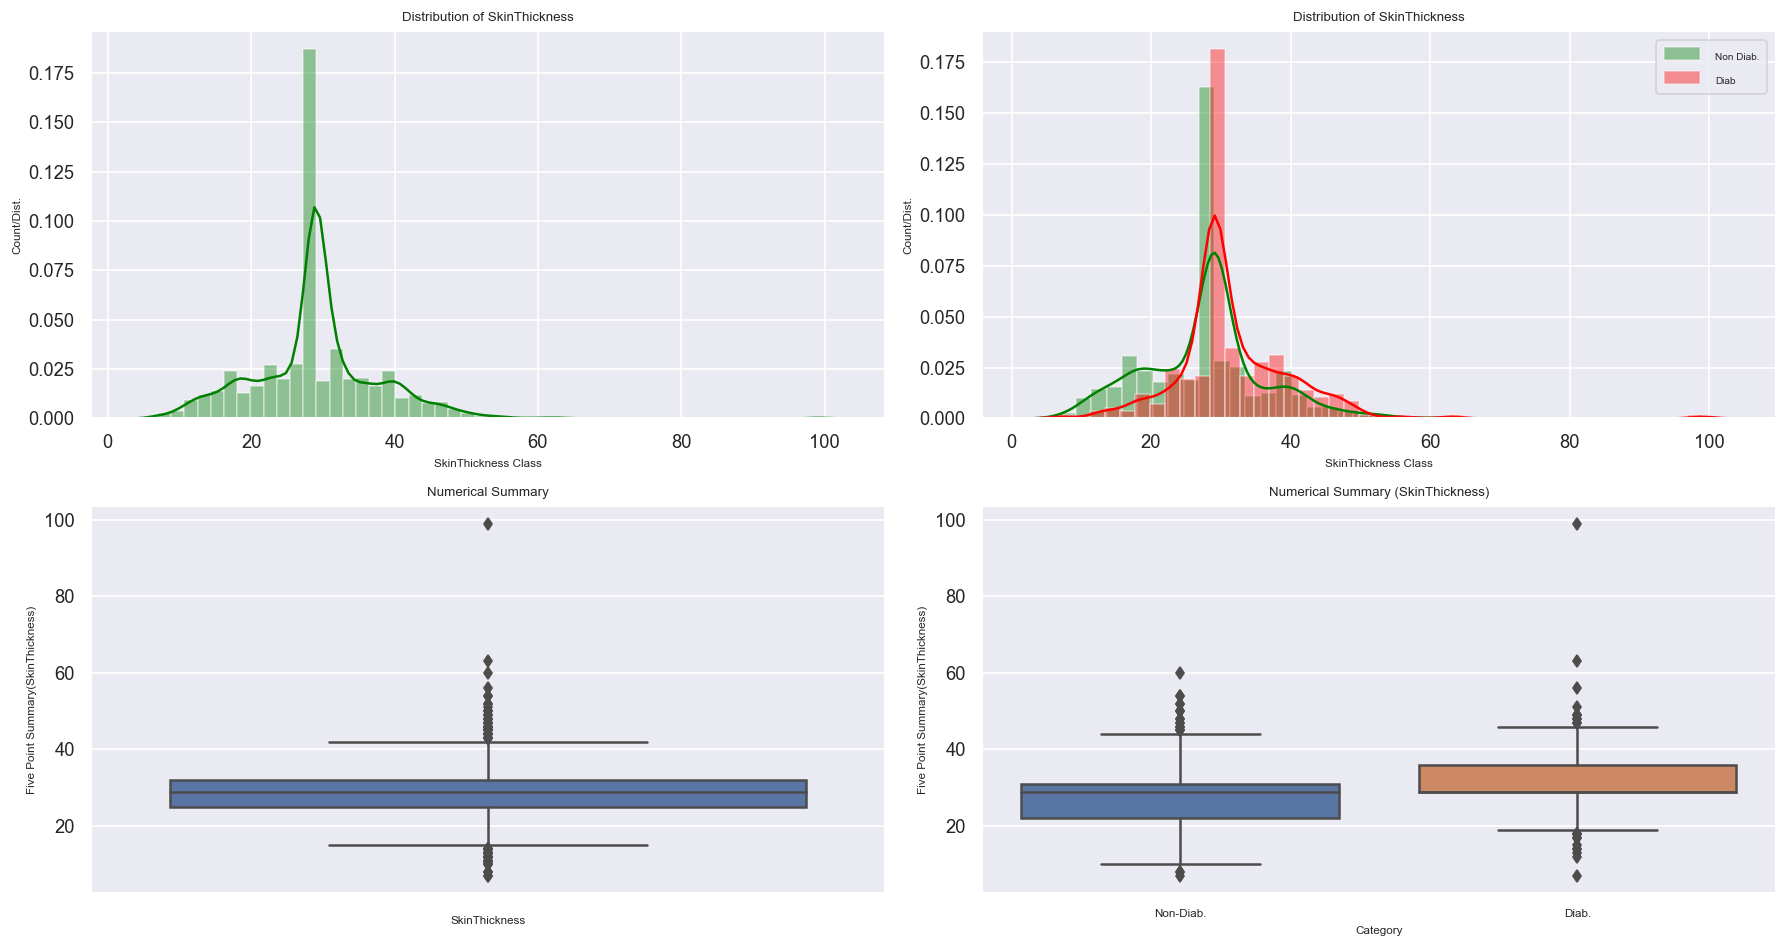

In [20]:
fig,axes = plt.subplots(nrows=2,ncols=2,dpi=120,figsize = (15,8))

# Plotting the distribution plot of Skin Thickness
plot00=sb.distplot(df['SkinThickness'],ax=axes[0][0],color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of SkinThickness',fontdict={'fontsize':8})
axes[0][0].set_xlabel('SkinThickness Class',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of Skin Thickness between diabetic and non-diabetic patients
plot01=sb.distplot(df[df['Outcome']==False]['SkinThickness'],ax=axes[0][1],color='green',label='Non Diab.')
sb.distplot(df[df.Outcome==True]['SkinThickness'],ax=axes[0][1],color='red',label='Diab')
axes[0][1].set_title('Distribution of SkinThickness',fontdict={'fontsize':8})
axes[0][1].set_xlabel('SkinThickness Class',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the boxplot of Skin Thickness
plot10=sb.boxplot(df['SkinThickness'],ax=axes[1][0],orient='v')
axes[1][0].set_title('Numerical Summary',fontdict={'fontsize':8})
axes[1][0].set_xlabel('SkinThickness',fontdict={'fontsize':7})
axes[1][0].set_ylabel(r'Five Point Summary(SkinThickness)',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of Skin Thickness between diabetic and non-diabetic patients
plot11=sb.boxplot(x='Outcome',y='SkinThickness',data=df,ax=axes[1][1])
axes[1][1].set_title(r'Numerical Summary (SkinThickness)',fontdict={'fontsize':8})
axes[1][1].set_ylabel(r'Five Point Summary(SkinThickness)',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
axes[1][1].set_xlabel('Category',fontdict={'fontsize':7})
plt.tight_layout()

plt.show()

The distribution of `Skin Thickness` in the dataset is:
* Normal and bell-shaped
* Centered at approximately `30`
* Most of the data between `25` and `33`
* Has a range of approximately `60`

# 5. Explanatory Analysis for the Variable `Insulin Level`

## 5.1 Summary Statistics for `Insulin Level`

In [21]:
#For the variable - Insulin Level

df.Insulin.describe()

count    768.000000
mean     140.671875
std       86.383060
min       14.000000
25%      121.500000
50%      125.000000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64

## 5.2 Distribution of the Variable `Insulin Level`and the Distribution Difference in `Insulin Level` Between Diabetic and Non-Diabetic Patients

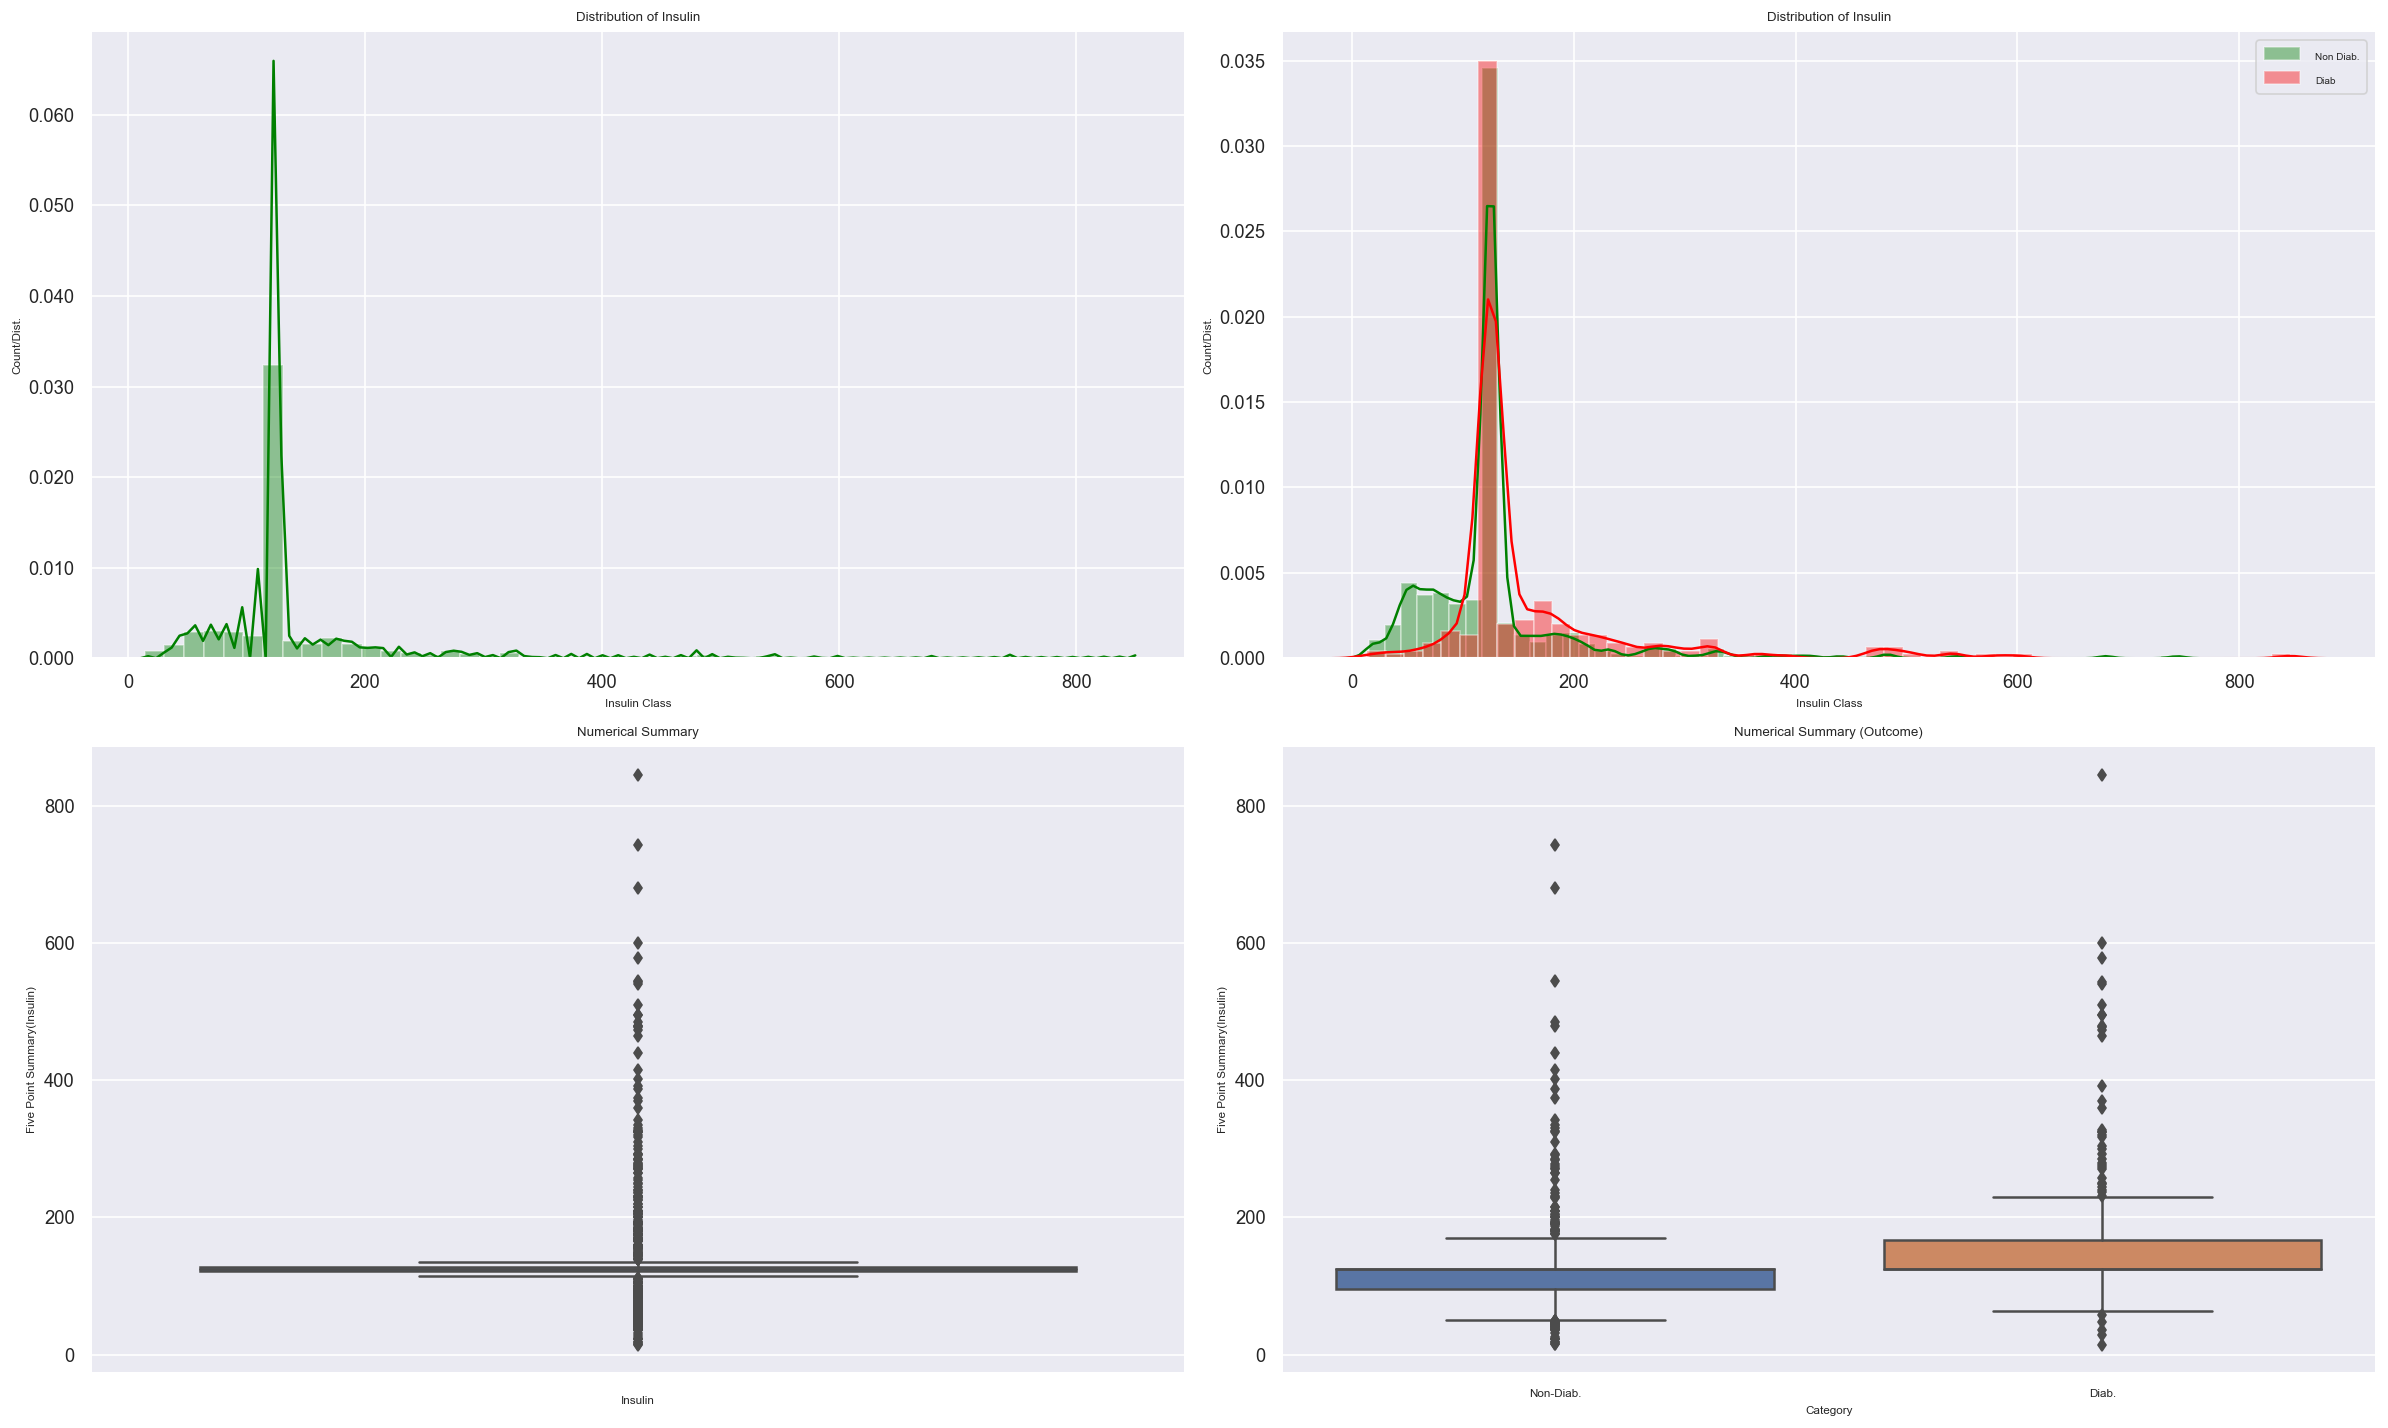

In [22]:
fig,axes = plt.subplots(nrows=2,ncols=2,dpi=120,figsize = (20,12))

# Plotting the distribution plot of Insulin Level
plot00=sb.distplot(df['Insulin'],ax=axes[0][0],color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of Insulin',fontdict={'fontsize':8})
axes[0][0].set_xlabel('Insulin Class',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of Insulin Level between diabetic and non-diabetic patients
plot01=sb.distplot(df[df['Outcome']==False]['Insulin'],ax=axes[0][1],color='green',label='Non Diab.')
sb.distplot(df[df.Outcome==True]['Insulin'],ax=axes[0][1],color='red',label='Diab')
axes[0][1].set_title('Distribution of Insulin',fontdict={'fontsize':8})
axes[0][1].set_xlabel('Insulin Class',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the boxplot of Insulin Level
plot10=sb.boxplot(df['Insulin'],ax=axes[1][0],orient='v')
axes[1][0].set_title('Numerical Summary',fontdict={'fontsize':8})
axes[1][0].set_xlabel('Insulin',fontdict={'fontsize':7})
axes[1][0].set_ylabel(r'Five Point Summary(Insulin)',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of Insulin Level between diabetic and non-diabetic patients
plot11=sb.boxplot(x='Outcome',y='Insulin',data=df,ax=axes[1][1])
axes[1][1].set_title(r'Numerical Summary (Outcome)',fontdict={'fontsize':8})
axes[1][1].set_ylabel(r'Five Point Summary(Insulin)',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
axes[1][1].set_xlabel('Category',fontdict={'fontsize':7})
plt.tight_layout()

plt.show()

The distribution of `Insulin Level` in the dataset is:
* Normal and bell-shaped
* Has the most number of outliers compared to the other variables
* More outliers are present on the right side of the distribution
* Centered at approximately `120`
* Most of the data between `100` and `150`
* Has a range of approximately `600`

# 6. Explanatory Analysis for the Variable `BMI Level`

## 6.1 Summary Statistics for `BMI Level`

In [23]:
#For the variable - BMI Level

df.BMI.describe()

count    768.000000
mean      32.457464
std        6.875151
min       18.200000
25%       27.500000
50%       32.400000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

## 6.2 Distribution of the Variable `BMI Level`and the Distribution Difference in `BMI Level` Between Diabetic and Non-Diabetic Patients

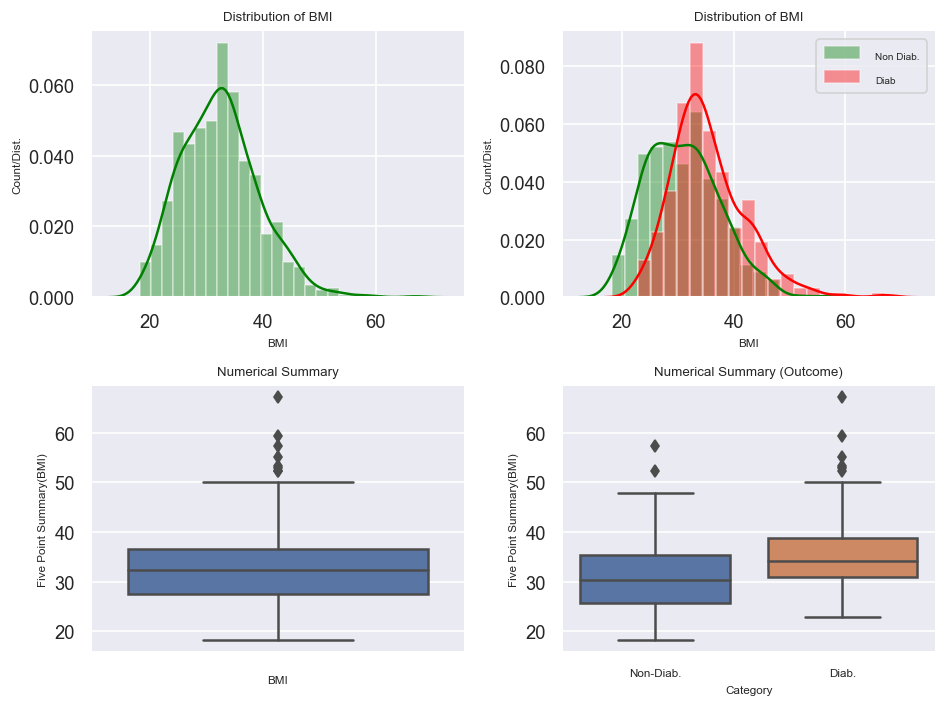

In [24]:
fig,axes = plt.subplots(nrows=2,ncols=2,dpi=120,figsize = (8,6))

# Plotting the distribution plot of BMI Level
plot00=sb.distplot(df['BMI'],ax=axes[0][0],color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of BMI',fontdict={'fontsize':8})
axes[0][0].set_xlabel('BMI',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of BMI Level between diabetic and non-diabetic patients
plot01=sb.distplot(df[df['Outcome']==False]['BMI'],ax=axes[0][1],color='green',label='Non Diab.')
sb.distplot(df[df.Outcome==True]['BMI'],ax=axes[0][1],color='red',label='Diab')
axes[0][1].set_title('Distribution of BMI',fontdict={'fontsize':8})
axes[0][1].set_xlabel('BMI',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the boxplot of BMI Level
plot10=sb.boxplot(df['BMI'],ax=axes[1][0],orient='v')
axes[1][0].set_title('Numerical Summary',fontdict={'fontsize':8})
axes[1][0].set_xlabel('BMI',fontdict={'fontsize':7})
axes[1][0].set_ylabel(r'Five Point Summary(BMI)',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of BMI Level between diabetic and non-diabetic patients
plot11=sb.boxplot(x='Outcome',y='BMI',data=df,ax=axes[1][1])
axes[1][1].set_title(r'Numerical Summary (Outcome)',fontdict={'fontsize':8})
axes[1][1].set_ylabel(r'Five Point Summary(BMI)',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
axes[1][1].set_xlabel('Category',fontdict={'fontsize':7})
plt.tight_layout()

plt.show()

The distribution of `BMI Level` in the dataset is:
* Approximately normal and bell-shaped
* More outliers are present on the right side of the distribution
* Centered at approximately `32`
* Most of the data between `28` and `37`
* Has a range of approximately `45`

The boxplots comparing the categories (diabetic and non-diabetic) suggests that people with higher BMI Levels have higher risk of diabetes.

# 7. Explanatory Analysis for the Variable `DiabetesPedigreeFunction`

## 7.1 Summary Statistics for `DiabetesPedigreeFunction`

In [25]:
#For the variable - DiabetesPedigreeFunction

df.DiabetesPedigreeFunction.describe()

count    768.000000
mean       0.471876
std        0.331329
min        0.078000
25%        0.243750
50%        0.372500
75%        0.626250
max        2.420000
Name: DiabetesPedigreeFunction, dtype: float64

## 7.2 Distribution of the Variable `DiabetesPedigreeFunction`and the Distribution Difference in `DiabetesPedigreeFunction` Between Diabetic and Non-Diabetic Patients

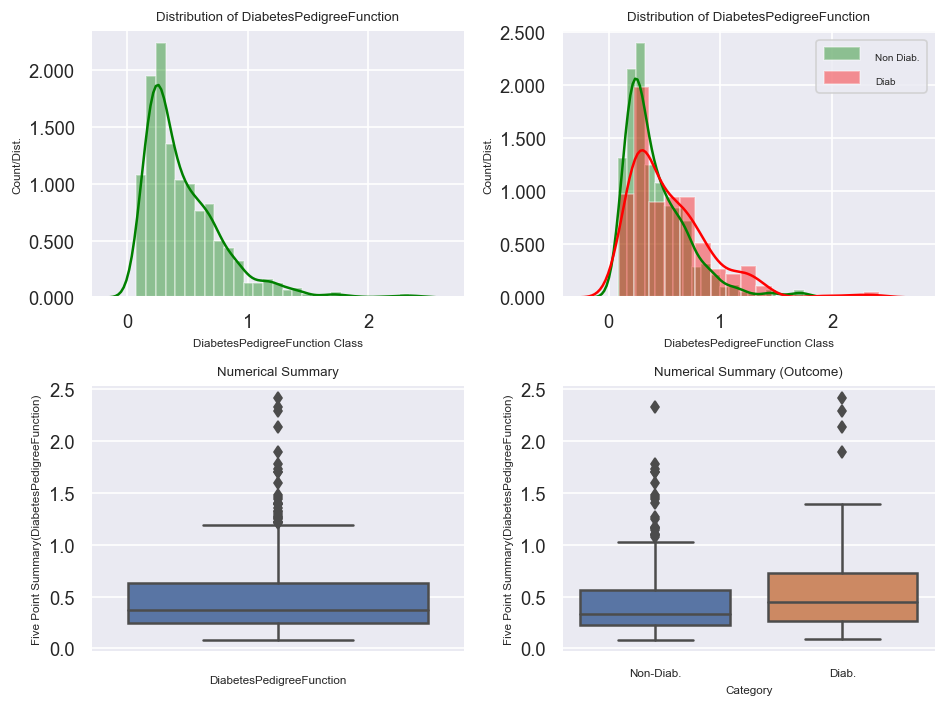

In [26]:
fig,axes = plt.subplots(nrows=2,ncols=2,dpi=120,figsize = (8,6))

# Plotting the distribution plot of DiabetesPedigreeFunction
plot00=sb.distplot(df['DiabetesPedigreeFunction'],ax=axes[0][0],color='green')
axes[0][0].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
axes[0][0].set_title('Distribution of DiabetesPedigreeFunction',fontdict={'fontsize':8})
axes[0][0].set_xlabel('DiabetesPedigreeFunction Class',fontdict={'fontsize':7})
axes[0][0].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting the distribution plot showing the difference in the distribution of DiabetesPedigreeFunction between diabetic and non-diabetic patients
plot01=sb.distplot(df[df['Outcome']==False]['DiabetesPedigreeFunction'],ax=axes[0][1],color='green',label='Non Diab.')
sb.distplot(df[df.Outcome==True]['DiabetesPedigreeFunction'],ax=axes[0][1],color='red',label='Diab')
axes[0][1].set_title('Distribution of DiabetesPedigreeFunction',fontdict={'fontsize':8})
axes[0][1].set_xlabel('DiabetesPedigreeFunction Class',fontdict={'fontsize':7})
axes[0][1].set_ylabel('Count/Dist.',fontdict={'fontsize':7})
axes[0][1].yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plot01.axes.legend(loc=1)
plt.setp(axes[0][1].get_legend().get_texts(), fontsize='6')
plt.setp(axes[0][1].get_legend().get_title(), fontsize='6')
plt.tight_layout()

# Plotting the boxplot of DiabetesPedigreeFunction
plot10=sb.boxplot(df['DiabetesPedigreeFunction'],ax=axes[1][0],orient='v')
axes[1][0].set_title('Numerical Summary',fontdict={'fontsize':8})
axes[1][0].set_xlabel('DiabetesPedigreeFunction',fontdict={'fontsize':7})
axes[1][0].set_ylabel(r'Five Point Summary(DiabetesPedigreeFunction)',fontdict={'fontsize':7})
plt.tight_layout()

# Plotting boxplots showing the difference in the distribution of DiabetesPedigreeFunction between diabetic and non-diabetic patients
plot11=sb.boxplot(x='Outcome',y='DiabetesPedigreeFunction',data=df,ax=axes[1][1])
axes[1][1].set_title(r'Numerical Summary (Outcome)',fontdict={'fontsize':8})
axes[1][1].set_ylabel(r'Five Point Summary(DiabetesPedigreeFunction)',fontdict={'fontsize':7})
plt.xticks(ticks=[0,1],labels=['Non-Diab.','Diab.'],fontsize=7)
axes[1][1].set_xlabel('Category',fontdict={'fontsize':7})
plt.tight_layout()

plt.show()

The distribution of `DiabetesPedigreeFunction` in the dataset is:
* Unimodal and right-skewed
* More outliers are present on the right side of the distribution
* Centered at approximately `0.375`
* Most of the data between `0.25` and `0.6`
* Has a range of approximately `2.4`

# 8. Data Visualisation for Unclean and Clean Data

## 8.1 Checking the Balance of the Data by Plotting the Count of Outcomes by their Value

0    500
1    268
Name: Outcome, dtype: int64


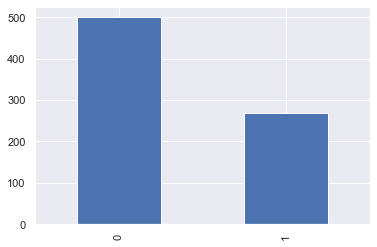

In [27]:
print(data.Outcome.value_counts())
data.Outcome.value_counts().plot(kind="bar")

The above graph shows that the data is biased towards datapoints having outcome value as 0 where it means that diabetes was not present actually. The number of non-diabetics is almost twice the number of diabetic patients

## 8.2 Pair Plot for Clean Data

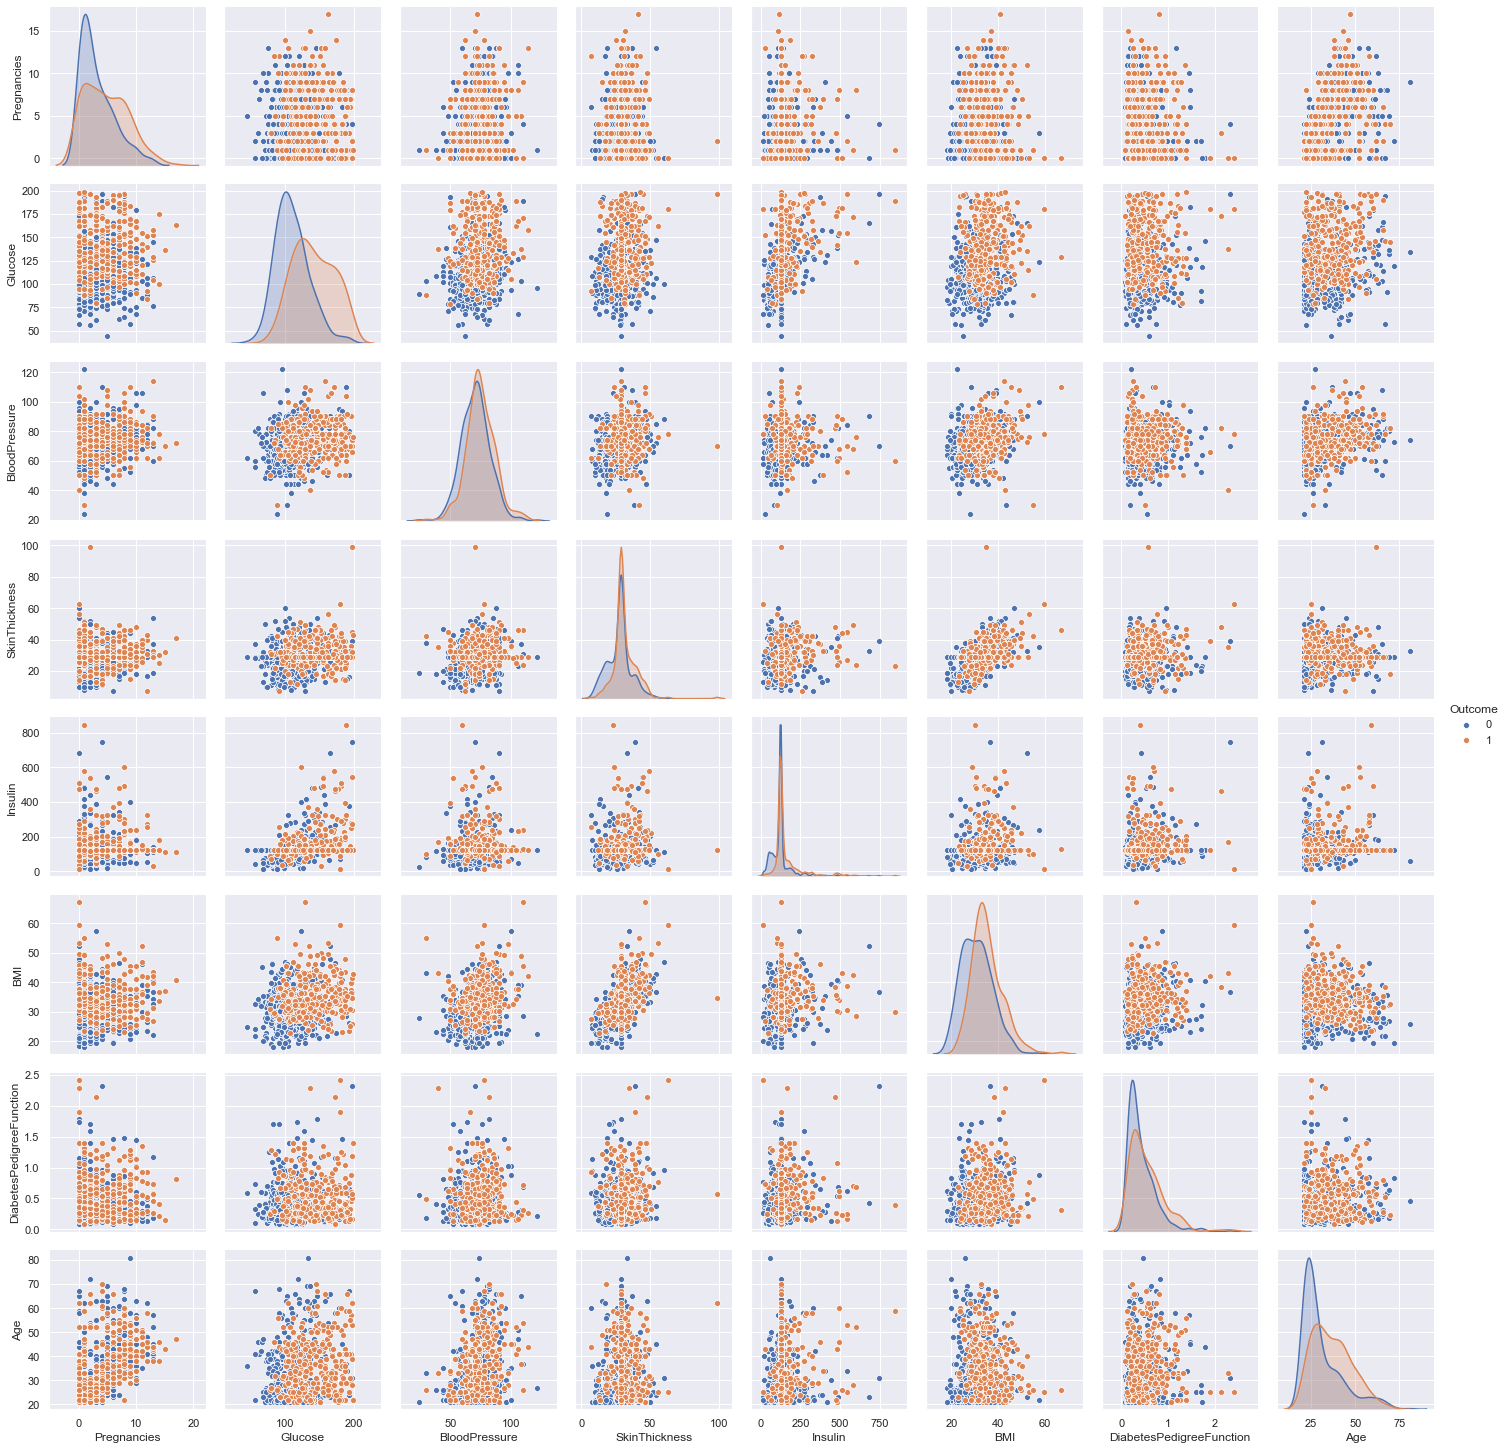

In [28]:
p=sb.pairplot(df, hue = 'Outcome')

## 8.3 Heat Maps for Unclean and Clean Data

### 8.3.1 Unclean Data

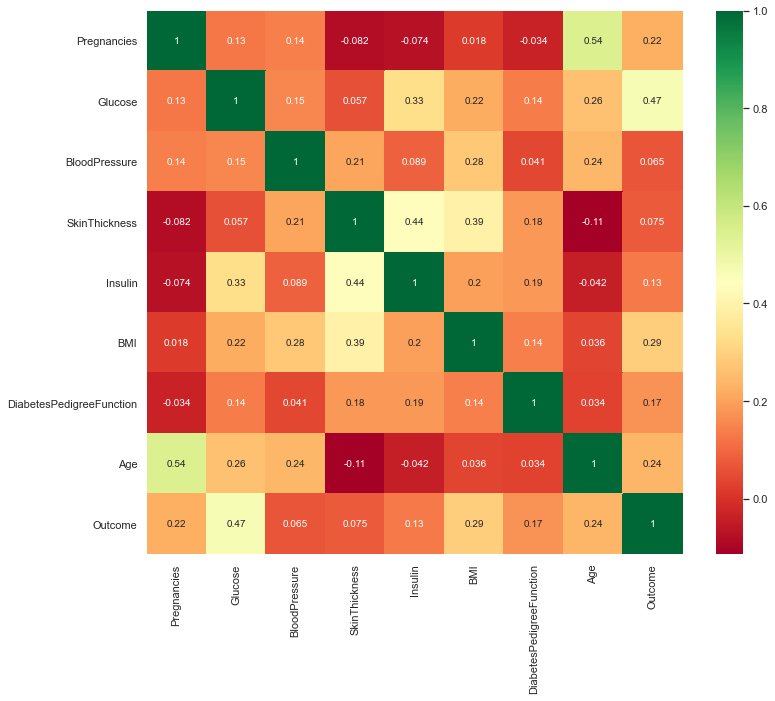

In [29]:
plt.figure(figsize=(12,10))
p=sb.heatmap(data.corr(), annot=True,cmap ='RdYlGn')

### 8.3.2 Clean Data

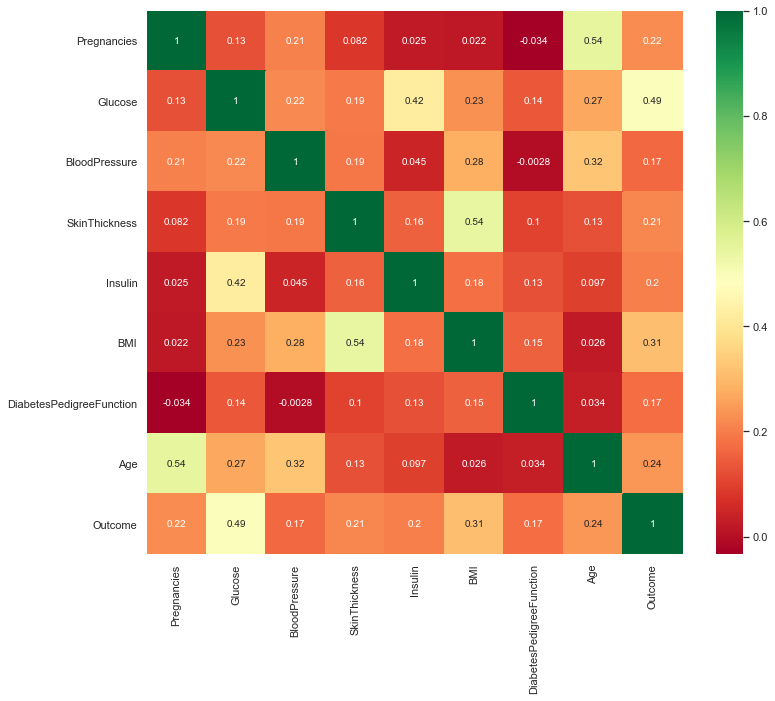

In [30]:
plt.figure(figsize=(12,10))
p=sb.heatmap(df.corr(), annot=True,cmap ='RdYlGn')

## 8.4 Pandas Profiling Tool Used for Visualisation of Unclean and Clean Data

### 8.4.1 Unclean Dataset

In [31]:
from pandas_profiling import ProfileReport
profile = ProfileReport(data, title="Pandas Profiling Report")

ModuleNotFoundError: No module named 'pandas_profiling'

In [ ]:
profile

### 8.4.2 Cleaned Dataset

In [ ]:
cleanedprofile = ProfileReport(df, title="Pandas Profiling Report")
cleanedprofile

# 9. Further Visualisation for Clean Data

In [32]:
data_cleaned = pd.DataFrame(data=df)

glucose = data_cleaned['Glucose']
pregnancies = data_cleaned['Pregnancies']
bloodpressure = data_cleaned['BloodPressure']
skinthickness = data_cleaned['SkinThickness']
insulin = data_cleaned['Insulin']
BMI = data_cleaned['BMI']
DPF = data_cleaned['DiabetesPedigreeFunction']
age = data_cleaned['Age']
outcome = data_cleaned['Outcome']

In [33]:
feature_cols = ['Pregnancies','Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
x = data_cleaned[feature_cols]
y = data_cleaned['Outcome']

#Splitting the cleaned data into Training sets and Testing sets for Machine Learning
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25)

## 9.1 Joint Plots of Variables against Outcome (whether a patient has diabetes or not)

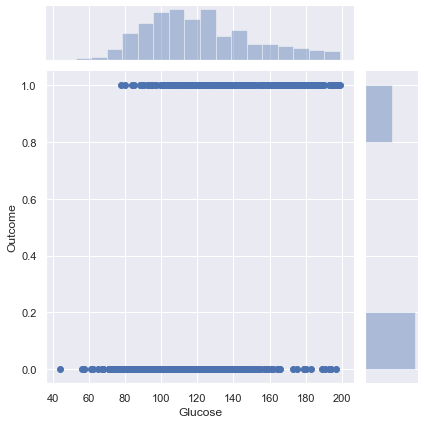

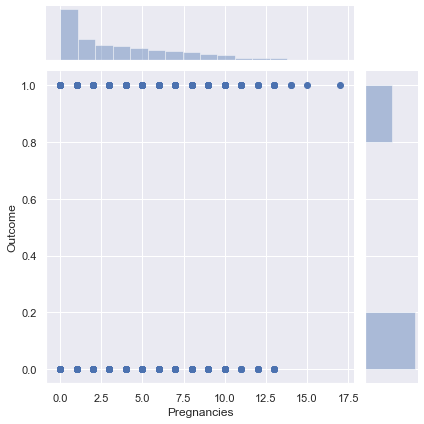

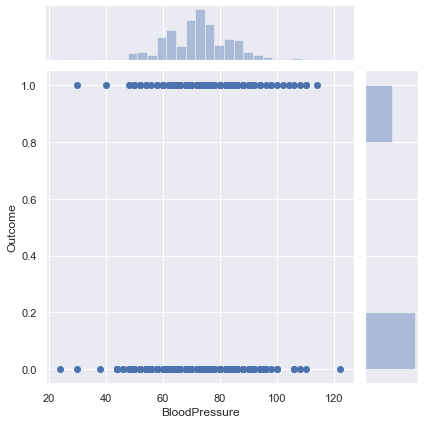

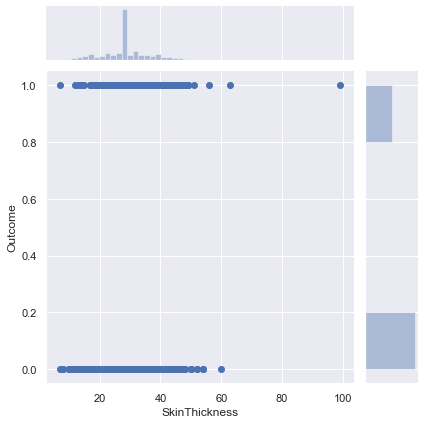

In [34]:
sb.jointplot(glucose,outcome)
sb.jointplot(pregnancies,outcome)
sb.jointplot(bloodpressure,outcome)
sb.jointplot(skinthickness,outcome)

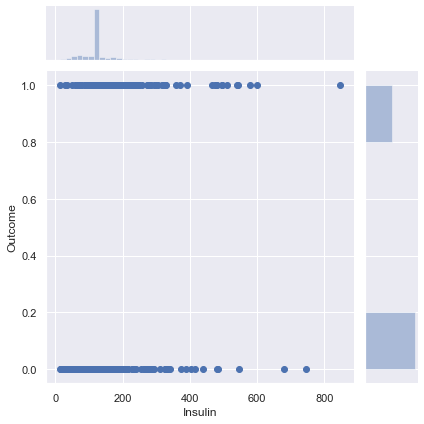

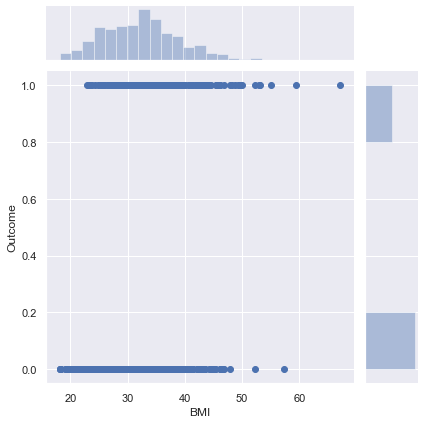

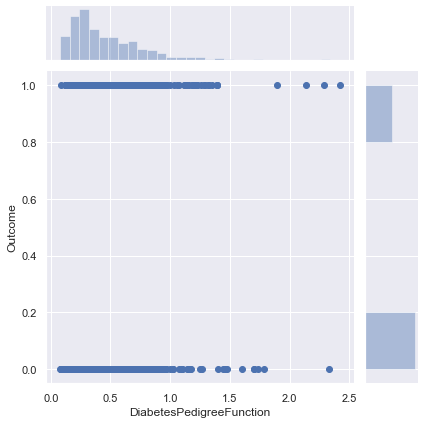

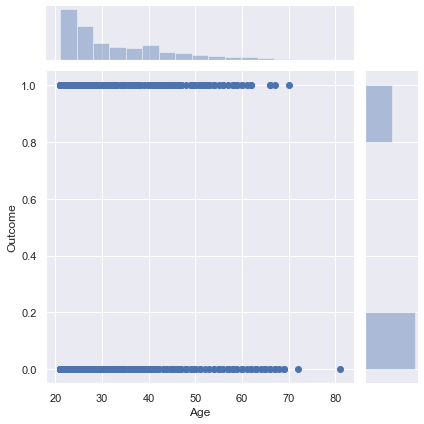

In [35]:
sb.jointplot(insulin,outcome)
sb.jointplot(BMI,outcome)
sb.jointplot(DPF,outcome)
sb.jointplot(age,outcome)  

# Section C: Machine Learning, Conclusion and Recommendations

(Done By: Kant Kaw Khin and Yeow Jun Wei)

## Machine Learning

We have chosen 4 Machine Learning methods to explore, namely the Decision Tree Classifier, Logistic Regression, Random Forest Classifier, and Naive Bayes Classifier. 

### 1. Decision Tree

Decision Tree Classifier is a supervised machine learning technique for inducing a decision tree from training data. A decision tree is a predictive model which is a mapping from observations about an item to conclusions about its target value. In our project, the decision tree concludes whether a patient has diabetes (1) or not (0) based on the variables `Pregnancies` ,`Glucose Levels`, `BloodPressure`, `SkinThickness`, `Insulin Level`, `BMI Level`, `DiabetesPedigreeFunction`, and `Age`.



#### 1.1 Decision Tree Classifier and Plotter Using Default Parameters and Max_Depth = 2

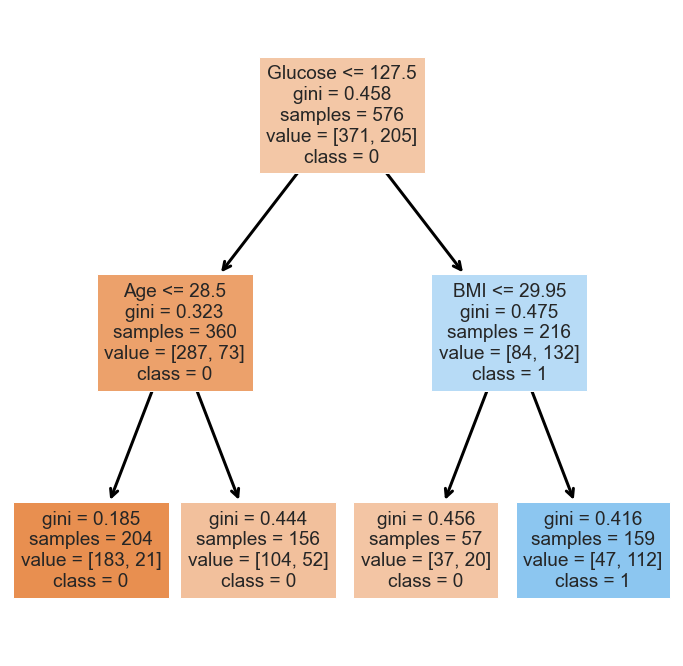

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.7569444444444444

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.8125



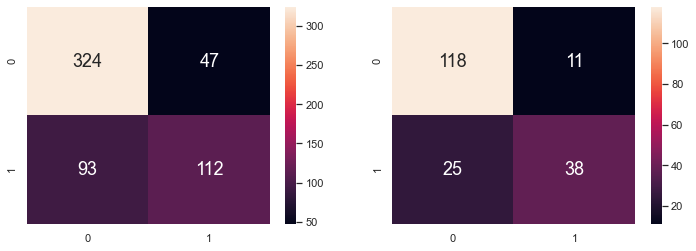

In [36]:
# Decision Tree using Train Data
dectree = DecisionTreeClassifier(max_depth = 2)  # create the decision tree object
dectree.fit(x_train, y_train)                    # train the decision tree model


from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(12, 12))
out = plot_tree(dectree, 
          feature_names = x_train.columns,
          class_names = [str(x) for x in dectree.classes_],
          filled=True)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(3)
        
plt.show()

# Predict Response corresponding to Predictors
y_train_pred = dectree.predict(x_train)
y_test_pred = dectree.predict(x_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(x_train, y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(x_test, y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

#### 1.2 Tuning the Parameters of the Decision Tree Classifier 

To optimise the Decision Tree Classifier and improve the classfication accuracy, we can look at the parameters of the model and find a combination that will produce the best results. In this project, we will be focusing on three main parameters of the Decision Tree Classifier- `max_depth`, `min_samples_split` and `min_samples_leaf`. 


The first parameter to tune is `max_depth`. This indicates how deep the tree can be. The deeper the tree, the more splits it has and it captures more information about the data. 

    max_depth  Accuracy (Train Data)  Accuracy (Test Data)
0         1.0               0.727431              0.760417
1         2.0               0.756944              0.812500
2         3.0               0.763889              0.802083
3         4.0               0.791667              0.755208
4         5.0               0.847222              0.755208
5         6.0               0.875000              0.750000
6         7.0               0.909722              0.739583
7         8.0               0.942708              0.723958
8         9.0               0.961806              0.750000
9        10.0               0.986111              0.708333
10       11.0               0.994792              0.723958
11       12.0               0.998264              0.697917
12       13.0               1.000000              0.718750
13       14.0               1.000000              0.718750
14       15.0               1.000000              0.718750



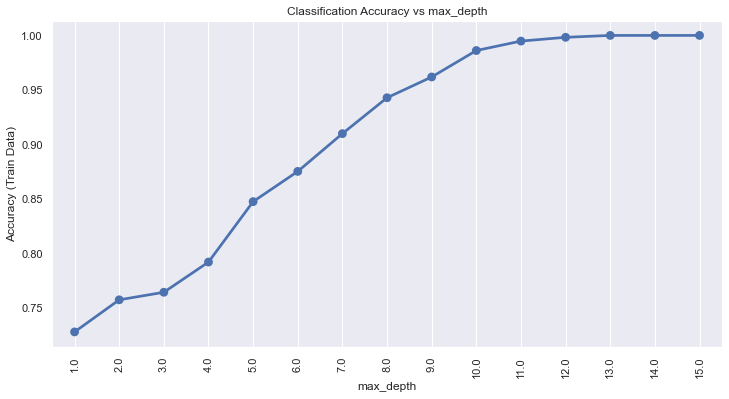

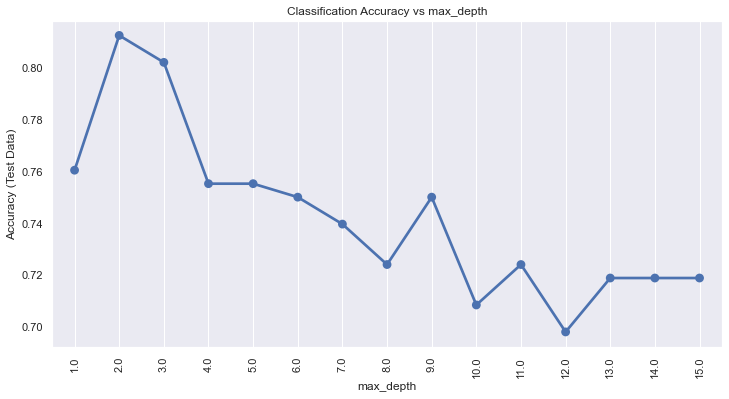

In [37]:
# To find the optimal value of max_depth, we test the accuracy for the model when max_depth ranges from 1 to 15.
c_parameter_name = 'max_depth'
c_parameter_values = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
accuracy = pd.DataFrame(columns=[c_parameter_name, 'Accuracy (Train Data)', 'Accuracy (Test Data)'])

# Here, we create a loop to test the accuracy of the model with different values of max_depth.
# Important Note: we only specify the max_depth and random_state values and set the rest of the parameters to default values in this model. 
for input_parameter in c_parameter_values:
    model = DecisionTreeClassifier(max_depth=input_parameter, random_state=42)
    model.fit(x_train, y_train)
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    acctr_score = model.score(x_train, y_train)
    accte_score = model.score(x_test, y_test)
    accuracy = accuracy.append({c_parameter_name : input_parameter , 'Accuracy (Train Data)' : acctr_score, 'Accuracy (Test Data)' : accte_score}, ignore_index=True)
    
print(accuracy)
print("")
plt.figure(figsize=(12,6))
sb.pointplot(x=c_parameter_name, y="Accuracy (Train Data)", data=accuracy)
title = 'Classification Accuracy vs ' + c_parameter_name 
plt.title(title)
plt.xticks(rotation= 90)
plt.grid()

plt.figure(figsize=(12,6))
sb.pointplot(x=c_parameter_name, y="Accuracy (Test Data)", data=accuracy)
title = 'Classification Accuracy vs ' + c_parameter_name 
plt.title(title)
plt.xticks(rotation= 90)
plt.grid()


Here, we can derive the optimal value of `max_depth` by looking at which model has the higgest accuracy rates using test data. While the accuracy for the models using train data is also important, we can see that it will never decrease as max_depth increases, and will continue to increase up to accuracy values of 1 where we might face a problem of over-fitting. Thus, we place more importance on the accuracy of the models using test data. 

As commented in the code above, we set the rest of the parameters (apart from `max_depth`) to default values in our model. 

To improve the accuracy of our Decision Tree Classifier even more, we can tune other parameters such as `min_samples_split` and `min_samples_leaf`. 

> `min_samples_split` : int, float, optional (default=2)
* The minimum number of samples required to split a node. If this parameter is set as 20 and if a node includes samples less than 20, it means this is the last node (which means terminal node or leaf) and it is not splittable any more.

> `min_samples_leaf` : int, float, optional (default=1)
* The minimum number of samples required to be at a leaf node. 

In order to find the best model with the optimal value for these three parameters, we use GridSearchCV which performs an exhaustive search over specified parameter values for an estimator. GridSearchCV implements a “fit” and a “score” method. It also implements “predict”, “predict_proba”, “decision_function”, “transform” and “inverse_transform” if they are implemented in the estimator used. The parameters of the estimator used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

#### 1.3 Best Decision Tree Classifier Model

DecisionTreeClassifier(max_depth=7, min_samples_leaf=17, random_state=42)


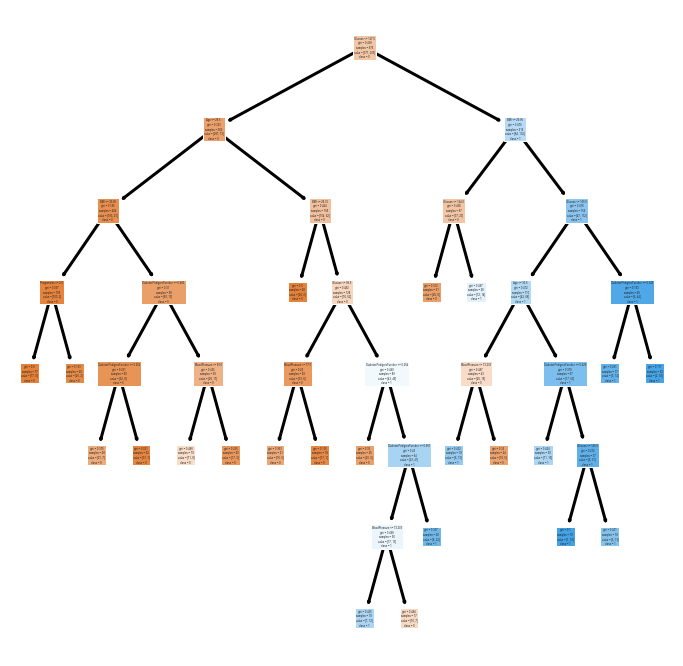

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.8211805555555556

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.78125



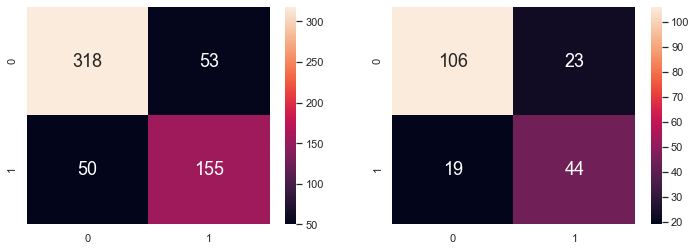

In [38]:
skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=268)
param_grid = {'max_depth': np.arange(1,15),
              'min_samples_split' : np.arange(2,20,2),
              'min_samples_leaf' : np.arange(1,21,2),
              'random_state' : [42]}

#create a grid
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, scoring = 'accuracy', n_jobs=-1, cv=skf)

#training
grid_tree.fit(x_train, y_train)

#let's see the best estimator
best_tree = grid_tree.best_estimator_
print(best_tree)

best_tree.fit(x_train, y_train)     

from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(12, 12))
out = plot_tree(best_tree, 
          feature_names = x_train.columns,
          class_names = [str(x) for x in best_tree.classes_],
          filled=True)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(3)
        
plt.show()

# Predict Response corresponding to Predictors
y_train_pred = best_tree.predict(x_train)
y_test_pred = best_tree.predict(x_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", best_tree.score(x_train, y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", best_tree.score(x_test, y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])


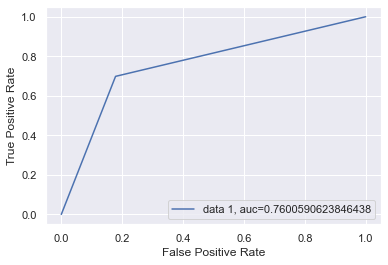

In [39]:
dtfpr, dttpr, _ = metrics.roc_curve(y_test, y_test_pred)
dtauc = metrics.roc_auc_score(y_test, y_test_pred)
plt.plot(dtfpr,dttpr,label="data 1, auc="+str(dtauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

### 2. Logistic Regression 

Linear Regression (be it univariate or multi-variate) will be ineffective here as the values we are trying to predict in `Outcome` are binary in nature (either 0 or 1). As a result, drawing a regression line to predict outcome values will be ineffective and the models trained will be inaccurate.

As such, it is imperative that we find a more appropriate model to use to predict the outcome values. As a result, we will use Logistic Regression as one of the models to predict binary dependent variables such as `Outcome`. 

Logistic Regression is a form of regression analysis; it is used when the dependent variable is dichotomous or binary. Like all regression analyses, the logistic regression is a predictive tool. It is used to describe data and explain the relationships between one dependent binary variable and one or more independent variables.

In our case, we are utilizing the Binary Logistic Regression Analysis as our dependent variable `Outcome` is binary, either Yes (1) or No (0).


In [40]:
import warnings
warnings.simplefilter(action='ignore')

logreg = LogisticRegression()

logreg.fit(x_train,y_train)

log_pred= logreg.predict(x_test)

#### 2.1 Confusion Matrix

In order to evaluate the performance of the classification model, a confusion matrix can be used to show the correct and incorrect predictions.

Text(0.5, 39.5, 'Predicted')

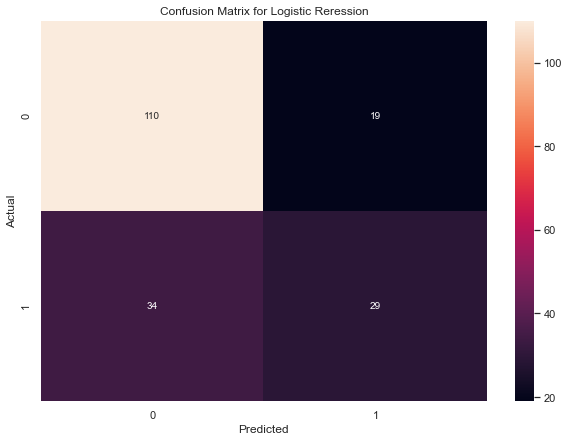

In [41]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(10,7))
sb.heatmap(cm, annot=True, fmt = 'g')
plt.title('Confusion Matrix for Logistic Reression', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

#### 2.2 Description of Metrics

Metrics are used to quantify the quality of a model's predictions.  

>`Accuracy Score` = (True Posititve + True Negative) / Total

>`Balanced Accuracy Score` = 0.5 * (True Positive Rate + True Negative Rate)

>`Precision Score` = True Positive / Actual Results OR True Posititve / (True Positive + True Negative) 

>`Recall Score` = True Posititve / Predicted Results OR True Positive / (True Positive + False Negative) 


In [42]:
print("Accuracy: ",metrics.accuracy_score(y_test, log_pred))
print("Balanced Accuracy Score: ",metrics.balanced_accuracy_score(y_test,log_pred))
print("Precision: ",metrics.precision_score(y_test, log_pred))
print("Recall: ",metrics.recall_score(y_test, log_pred))

Accuracy:  0.7239583333333334
Balanced Accuracy Score:  0.6565153193060169
Precision:  0.6041666666666666
Recall:  0.4603174603174603


> `ROC Curve:` Receiver Operating Characteristic Curve

The Receiver Operating Characteristics (ROC) summarizes the prediction performance of a classification model at all classification thresholds. In essence, the ROC curve plots the true positive rate (y-axis) against the false positive rate (x-axis). 

> `ROC AUC Score:` Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores.

The Area Under the Curve (AUC) metric indicates the degree or measure of separability (ability to distinguish if the outcome is a 1 or 0). The closer the score is to 1, the better the ability of the model to predict the outcome. 

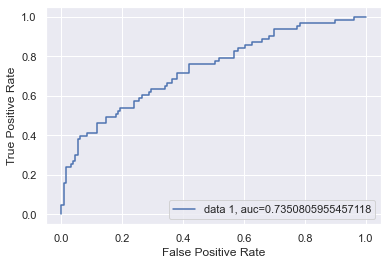

In [43]:
log_prob = logreg.predict_proba(x_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  log_prob)
lgauc = metrics.roc_auc_score(y_test, log_prob)
plt.plot(fpr,tpr,label="data 1, auc="+str(lgauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

>`log_prob = logreg.predict_proba(x_test)[::,1]`

Probabilities for the positive outcome is kept.

### 3. Random Forest Classification

Thirdly, we will be using the Random Forest Classificaiton Model.

The Random Forest Classification works by having a large number of individual decision trees that operate as an ensemble. Each individual tree in the random forest spits out a class prediction and the class with the most votes becomes the model’s prediction. 

In our case, the number of trees that we are utilizing is 100, hence `n_estimators = 100` 

In [44]:
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(x_train, y_train)

rf_prob = random_forest.predict_proba(x_test)[::,1]
rf_pred = random_forest.predict(x_test)

#### 3.1 Feature Importances 

The measurements of importances of the features in the Random Forest Classification problem is based of the Gini Impurity or Information Gain. When we train a tree, we compute how much each feature contributes to decreasing the weighted impurity. We are using `feature_importances_`; this function aims at averaging the decrease in impurity over trees.


From this, we are able to see that `Glucose` is the most important feature. 

In [45]:
importances = pd.DataFrame({'feature':x_train.columns,'importance':np.round(random_forest.feature_importances_,3)})
importances = importances.sort_values('importance',ascending=False).set_index('feature')
importances.head(8)

,importance
feature,
Glucose,0.240
BMI,0.162
Age,0.136
DiabetesPedigreeFunction,0.131
Insulin,0.094
BloodPressure,0.087
Pregnancies,0.076
SkinThickness,0.074



Instead of viewing the importance of the features in a Data Frame, visualizing the importances in a bar chart can be more useful. 


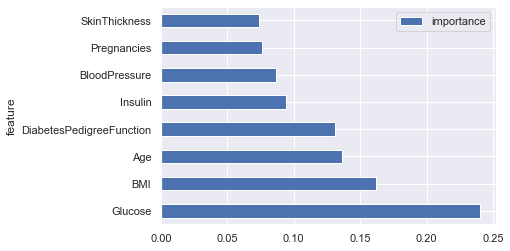

In [46]:
importances.plot.barh()

Once again, we can use a confusion matrix to show the correct and incorrect predictions in order to evaluate the effectiveness of our model.

Text(0.5, 39.5, 'Predicted')

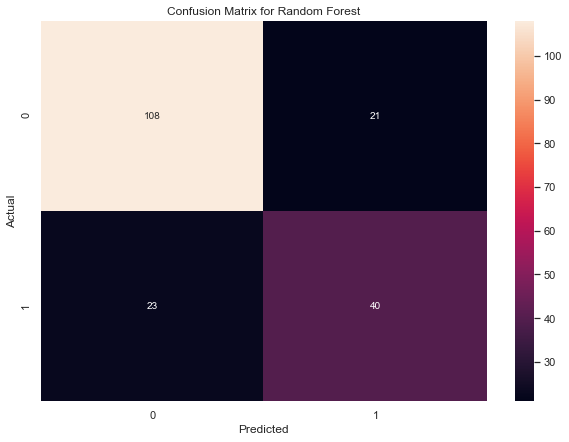

In [47]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(10,7))
sb.heatmap(cm_rf, annot=True, fmt = 'g')
plt.title('Confusion Matrix for Random Forest', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [48]:
print("Accuracy: ",metrics.accuracy_score(y_test, rf_pred))
print("Balanced Accuracy Score: ",metrics.balanced_accuracy_score(y_test,rf_pred))
print("Precision: ",metrics.precision_score(y_test, rf_pred))
print("Recall: ",metrics.recall_score(y_test, rf_pred))

Accuracy:  0.7708333333333334
Balanced Accuracy Score:  0.7360649686231082
Precision:  0.6557377049180327
Recall:  0.6349206349206349


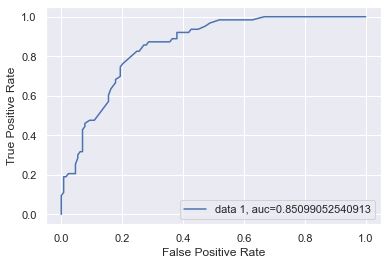

In [49]:
rffpr, rftpr, _ = metrics.roc_curve(y_test, rf_prob)
rfauc = metrics.roc_auc_score(y_test, rf_prob)
plt.plot(rffpr,rftpr,label="data 1, auc="+str(rfauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

### 4. Gaussian Naive Bayes 

Naive Bayes is a classification algorithm for binary (two-class) and multi-class classification problems. The technique is easiest to understand when described using binary or categorical input values.

Gaussian Naive Bayes is an extension of the Naive Bayes Theorem. Other functions can be used to estimate the distribution of the data, but the Gaussian (or Normal distribution) is the easiest to work with because it aids to estimate the mean and standard deviation from the training data.

At this point, we are starting the GaussianNB.

In [50]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(x_train, y_train)
nb_prob = nb.predict_proba(x_test)[::,1]

In [51]:
nb_pred = nb.predict(x_test)

print("Accuracy: ",metrics.accuracy_score(y_test, nb_pred))
print("Balanced Accuracy Score: ",metrics.balanced_accuracy_score(y_test,nb_pred))
print("Precision: ",metrics.precision_score(y_test, nb_pred))
print("Recall: ",metrics.recall_score(y_test, nb_pred))

Accuracy:  0.796875
Balanced Accuracy Score:  0.7554448135843485
Precision:  0.7142857142857143
Recall:  0.6349206349206349


Text(0.5, 39.5, 'Predicted')

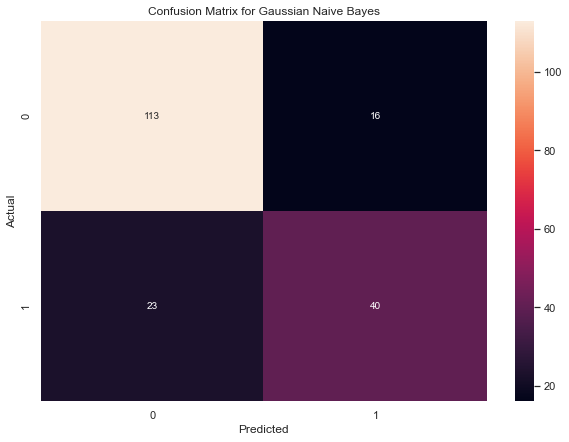

In [52]:
cm_nb = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(10,7))
sb.heatmap(cm_nb, annot=True, fmt = 'g')
plt.title('Confusion Matrix for Gaussian Naive Bayes', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

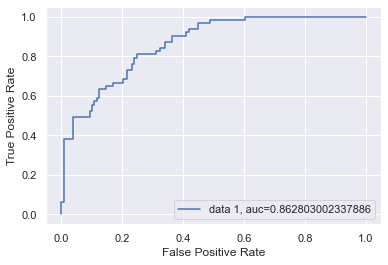

In [53]:
nbfpr, nbtpr, _ = metrics.roc_curve(y_test, nb_prob)
nbauc = metrics.roc_auc_score(y_test, nb_prob)
plt.plot(nbfpr,nbtpr,label="data 1, auc="+str(nbauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

### 5. Analysis of the Models

Now, we will begin comparing the 4 classification models we used in our project: Decision Tree, Random Forest, Logsitic Regression and Naive Bayes.

We will be using the common metric of ROC AUC, which indicates the degree and quality of the model to predict whether the outcome will be 1 or 0. 

In [54]:
print('Decision Tree: AUROC = %.4f' % (dtauc))
print('Random Forest: AUROC = %.4f' % (rfauc))
print('Naive Bayes: AUROC = %.4f' % (nbauc))
print('Logistic Regression: AUROC = %.4f' % (lgauc))

Decision Tree: AUROC = 0.7601
Random Forest: AUROC = 0.8510
Naive Bayes: AUROC = 0.8628
Logistic Regression: AUROC = 0.7351


In [55]:
dt_fpr, dt_tpr, _ = roc_curve(y_test, y_test_pred)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
lg_fpr, lg_tpr, _ = roc_curve(y_test, log_prob)

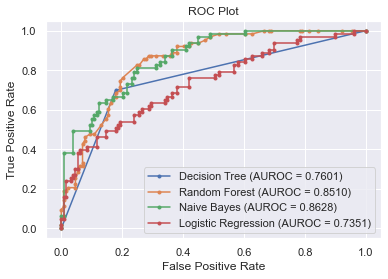

In [56]:
plt.plot(dt_fpr, dt_tpr, marker='.', label='Decision Tree (AUROC = %0.4f)' % dtauc)
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random Forest (AUROC = %0.4f)' % rfauc)
plt.plot(nb_fpr, nb_tpr, marker='.', label='Naive Bayes (AUROC = %0.4f)' % nbauc)
plt.plot(lg_fpr, lg_tpr, marker='.', label='Logistic Regression (AUROC = %0.4f)' % lgauc)

plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()  
plt.show()

### 6. Improving the Models

Now, using the importance features from the Random Forest Classification, we will select the 4 most important variables and use them exclusively to improve our models.

By using the factors with the most importance, it should help us improve the accuracy of the predictions of our models.

In [57]:
new_factors = data_cleaned[['Glucose', 'DiabetesPedigreeFunction', 'BMI', 'Age']]

In [58]:
newx = new_factors
newy = data_cleaned['Outcome']

newx_train, newx_test, newy_train, newy_test = train_test_split(newx,newy,test_size=0.25)

#### 6.1 New Decision Tree Classifier 

Running the decision tree classifier with the new selected features:

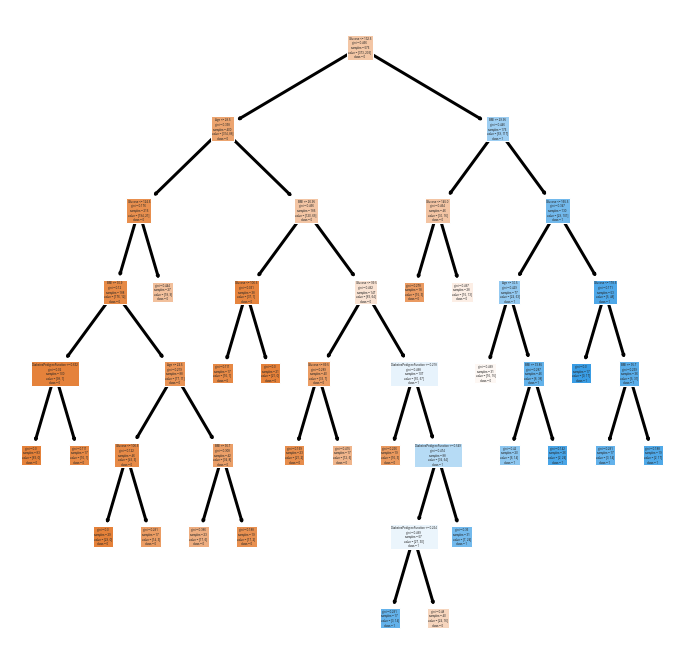

Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.8229166666666666

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.7395833333333334



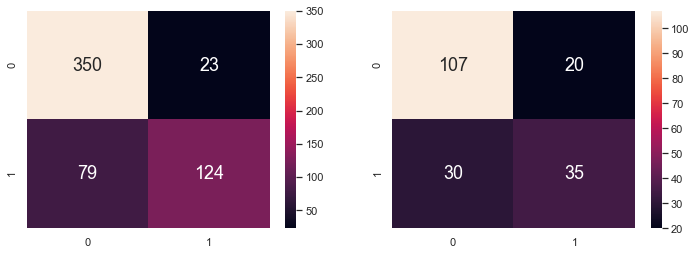

In [59]:
best_tree.fit(newx_train, newy_train)     

from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(12, 12))
out = plot_tree(best_tree, 
          feature_names = newx_train.columns,
          class_names = [str(x) for x in best_tree.classes_],
          filled=True)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(3)
        
plt.show()

# Predict Response corresponding to Predictors
newy_train_pred = best_tree.predict(newx_train)
newy_test_pred = best_tree.predict(newx_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", best_tree.score(newx_train, newy_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", best_tree.score(newx_test, newy_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(newy_train, newy_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(newy_test, newy_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

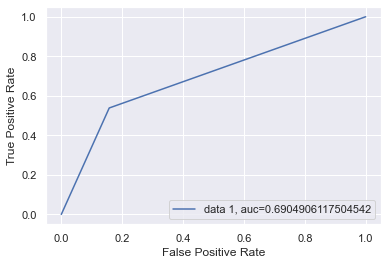

In [60]:
dt2fpr, dt2tpr, _ = metrics.roc_curve(newy_test, newy_test_pred)
newdtauc = metrics.roc_auc_score(newy_test, newy_test_pred)
plt.plot(dt2fpr, dt2tpr,label="data 1, auc="+str(newdtauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

#### 6.2 New Logistic Regression

Running the logistic regression with the new selected features:


In [61]:
logreg2 = LogisticRegression()

logreg2.fit(newx_train,newy_train)

newlg_pred = logreg2.predict(newx_test)

Text(0.5, 12.5, 'Predicted')

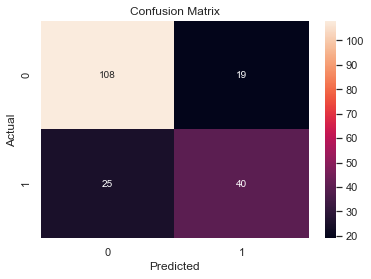

In [62]:
cm_lg2 = metrics.confusion_matrix(newy_test, newlg_pred)
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sb.heatmap(pd.DataFrame(cm_lg2), annot=True ,fmt='g')
plt.title('Confusion Matrix', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [63]:
print("Accuracy: ",metrics.accuracy_score(newy_test, newlg_pred))
print("Balanced Accuracy Score: ",metrics.balanced_accuracy_score(newy_test,newlg_pred))
print("Precision: ",metrics.precision_score(newy_test, newlg_pred))
print("Recall: ",metrics.recall_score(newy_test, newlg_pred))

Accuracy:  0.7708333333333334
Balanced Accuracy Score:  0.7328891580860085
Precision:  0.6779661016949152
Recall:  0.6153846153846154


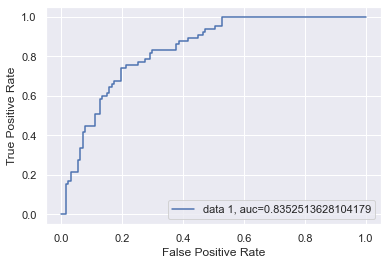

In [64]:
newlg_prob = logreg2.predict_proba(newx_test)[::,1]
lg2fpr, lg2tpr, _ = metrics.roc_curve(newy_test,  newlg_prob)
lg2auc = metrics.roc_auc_score(newy_test, newlg_prob)
plt.plot(lg2fpr,lg2tpr,label="data 1, auc="+str(lg2auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

#### 6.3 New Random Forest

Implementing Random Forest with the new selected features:

In [65]:
random_forest2 = RandomForestClassifier(n_estimators=100)
random_forest2.fit(newx_train, newy_train)

newrf_prob = random_forest2.predict_proba(newx_test)[::,1]
newrf_pred = random_forest2.predict(newx_test)


Text(0.5, 12.5, 'Predicted')

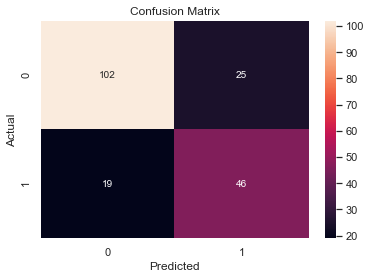

In [66]:
cm_rf2 = metrics.confusion_matrix(newy_test, newrf_pred)
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sb.heatmap(pd.DataFrame(cm_rf2), annot=True ,fmt='g')
plt.title('Confusion Matrix', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [67]:
print("Accuracy: ",metrics.accuracy_score(newy_test, newrf_pred))
print("Balanced Accuracy Score: ",metrics.balanced_accuracy_score(newy_test,newrf_pred))
print("Precision: ",metrics.precision_score(newy_test, newrf_pred))
print("Recall: ",metrics.recall_score(newy_test, newrf_pred))

Accuracy:  0.7708333333333334
Balanced Accuracy Score:  0.7554209569957602
Precision:  0.647887323943662
Recall:  0.7076923076923077


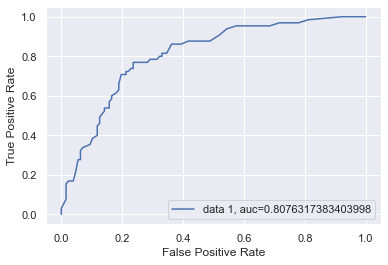

In [68]:
newrffpr, newrftpr, _ = metrics.roc_curve(newy_test,  newrf_prob)
newrfauc = metrics.roc_auc_score(newy_test, newrf_prob)
plt.plot(newrffpr,newrftpr,label="data 1, auc="+str(newrfauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

#### 6.4 New Gaussian Naive Bayes

Using Gaussian Naive Bayes with the new selected features:

In [69]:
nb2 = GaussianNB()
nb2.fit(newx_train, newy_train)
newnb_prob = nb2.predict_proba(newx_test)[::,1]

newnb_pred = nb2.predict(newx_test)

Text(0.5, 39.5, 'Predicted')

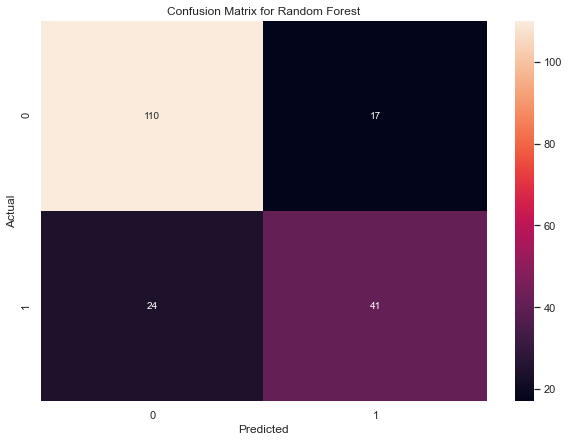

In [70]:
cm_nb2 = confusion_matrix(newy_test, newnb_pred)
plt.figure(figsize=(10,7))
sb.heatmap(cm_nb2, annot=True, fmt = 'g')
plt.title('Confusion Matrix for Random Forest', y=1.1)
plt.ylabel('Actual')
plt.xlabel('Predicted')

In [71]:
print("Accuracy: ",metrics.accuracy_score(newy_test, newrf_pred))
print("Balanced Accuracy Score: ",metrics.balanced_accuracy_score(newy_test,newrf_pred))
print("Precision: ",metrics.precision_score(newy_test, newrf_pred))
print("Recall: ",metrics.recall_score(newy_test, newrf_pred))

Accuracy:  0.7708333333333334
Balanced Accuracy Score:  0.7554209569957602
Precision:  0.647887323943662
Recall:  0.7076923076923077


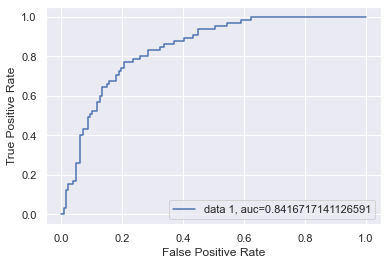

In [72]:
nb2fpr, nb2tpr, _ = metrics.roc_curve(newy_test, newnb_prob)
newnbauc = metrics.roc_auc_score(newy_test, newnb_prob)
plt.plot(nb2fpr,nb2tpr,label="data 1, auc="+str(newnbauc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc=4)
plt.show()

#### 6.5 Comparisons with the Previous Set of Models

Now that we have established new models using the most important features, we will now evaluate the quality and reliability of the models to predict the outcomes. 

In [73]:
print('Decision Tree: AUROC = %.4f' % (newdtauc))
print('Random Forest: AUROC = %.4f' % (newrfauc))
print('Naive Bayes: AUROC = %.4f' % (newnbauc))
print('Logistic Regression: AUROC = %.4f' % (lg2auc))

Decision Tree: AUROC = 0.6905
Random Forest: AUROC = 0.8076
Naive Bayes: AUROC = 0.8417
Logistic Regression: AUROC = 0.8353


We can compare the ROC AUC of the Old and New Models. 

>The `ROC AUC` is the degree or measure of separability (ability to distinguish if the outcome is a 1 or 0).

In [74]:
compar = pd.DataFrame(np.array([[dtauc, newdtauc], [rfauc, newrfauc], [nbauc, newnbauc], [lgauc, lg2auc]]), 
                      columns=['Old ROC AUC', 'New ROC AUC'], 
                      index =['Decision Tree','Random Forest', 'Gaussian Naive Bayes', 'Logistic Regression'])
compar

,Old ROC AUC,New ROC AUC
Decision Tree,0.760059,0.690491
Random Forest,0.850991,0.807632
Gaussian Naive Bayes,0.862803,0.841672
Logistic Regression,0.735081,0.835251


In [75]:
dt_fpr2, dt_tpr2, _ = roc_curve(newy_test, newy_test_pred)
rf_fpr2, rf_tpr2, _ = roc_curve(newy_test, newrf_prob)
nb_fpr2, nb_tpr2, _ = roc_curve(newy_test, newnb_prob)
lg_fpr2, lg_tpr2, _ = roc_curve(newy_test, newlg_prob)

#### 6.5.1 Comparisons of the 2 ROC Plots (New vs Old)

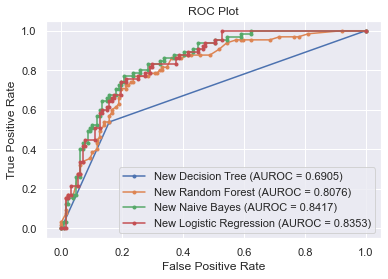

In [76]:
plt.plot(dt_fpr2, dt_tpr2, marker='.', label='New Decision Tree (AUROC = %0.4f)' % newdtauc)
plt.plot(rf_fpr2, rf_tpr2, marker='.', label='New Random Forest (AUROC = %0.4f)' % newrfauc)
plt.plot(nb_fpr2, nb_tpr2, marker='.', label='New Naive Bayes (AUROC = %0.4f)' % newnbauc)
plt.plot(lg_fpr2, lg_tpr2, marker='.', label='New Logistic Regression (AUROC = %0.4f)' % lg2auc)

plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()  
plt.show()

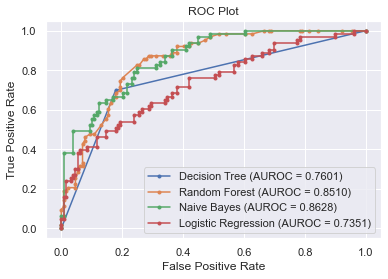

In [77]:
plt.plot(dt_fpr, dt_tpr, marker='.', label='Decision Tree (AUROC = %0.4f)' % dtauc)
plt.plot(rf_fpr, rf_tpr, marker='.', label='Random Forest (AUROC = %0.4f)' % rfauc)
plt.plot(nb_fpr, nb_tpr, marker='.', label='Naive Bayes (AUROC = %0.4f)' % nbauc)
plt.plot(lg_fpr, lg_tpr, marker='.', label='Logistic Regression (AUROC = %0.4f)' % lgauc)

plt.title('ROC Plot')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()  
plt.show()

Based off the ROC plots and subsequently the AUROC values, we can conclude that our models' accuracy and reliability did improve after we selected the appropriate features. 


### 7. Comparison of Machine Learning Methods

Random Forest Classification tends to do better than the Decision Tree Classfication, although minimally. This minimal difference could be due to the fact that there is not much variance or instability in the Decision Tree Model to begin with, as well as the fact that there are few features, or less deep decision trees.

For our dataset, the Naive Bayes Model did better than Decision Tree and Random Forest Models. This could be due to the fact that our variables are mostly Gaussian distributed, with the exception of `Preganancies` and `DiabetesePedigreeFunction`, enhancing the performance of the classifier as compared to the Decision Tree and Random Forest Models. However, Naïve Bayes has a naive assumption of conditional independence for every predictor, which means that the algorithm expects the variables `Pregnancies`,`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age` to be entirely independent of one another. This might not be the case in reality, as variables like `SkinThickness` may not be independent from variables like `Age` and `BMI`. Since rthe Logistic Regression Model splits data space linearly, and typically works reasonably well even when some of the variables are correlated, the Logistic Regression Model's performance is the best in comparison to the three other Machine Learning Methods. 

In conclusion, our best classification method is the Logistic Regression Model. It is possible to predict whether a patient has diabetes based on certain diagnostic measurements, with the attributes `Pregnancies`,`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, and `Age`.

## Project Conclusion and Recommendations

* The Top 4 most important features in predicting whether a patient has diabetes are:
   1. Glucose - Plasma glucose concentration a 2 hours in an oral glucose tolerance test
   2. DiabetesPedigreeFunction - A synthesis of the diabetes mellitus history in relatives and the genetic relationship of those relatives to the subject
   3. BMI - Body mass index (weight in kg/(height in m)^2)
   4. Age
 
 
* We used 4 different models, in which Logistic Regression performed the best, followed by Naive Bayes Classification, Random Forest Classification, and then Decision Tree Classification.


* Still, we wish to acknowledge the limitations of our dataset and predictors, for our particular problem statement. 

## Project Workload Allocation
Section A: Data Cleaning (Ho Jia Jun)

Section B: Data Preparation, Exploratory Analysis (Foo Kok Cheng)

Section C: Machine Learning, Conclusion and Recommendations (Kant Kaw Khin and Yeow Jun Wei)